# Fault Diagnosis for ADMIRE Model


## 0. Setup

In [2]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import immrax as irx
print(jax.devices())

[CudaDevice(id=0)]


In [ ]:
import os, sys
import pickle

sys.path.append("/home/user/output_feedback/nhholyap/examples/")
from functools import partial
from jax import jit, lax, vmap
import matplotlib.pyplot as plt
from admire import AdmireNineDoFLinAct
from faulty_car.interval_functions import overlap_size_lax, overlap_size, overlap_sum_lax, overlap_size_lax_scaled
import time, copy
from typing import Optional, Dict, Any, Tuple, List
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Rectangle

The actuator-linear ADMIRE model has the following inputs:

u = [right canard, 

    left canard, 

    right outboard elevon, 

    right inboard elevon,

    left inboard elevon,

    left outboard elevon, 

    rudder, 

    flaps,

    yaw thrust vectoring, 
    
    pitch thrust vectoring]

In [5]:
admire = AdmireNineDoFLinAct()
x0_admire = jnp.zeros(9)
x0_admire = x0_admire.at[0].set(343 * 0.3)  # Set the first joint to 1.0
x0_interval_admire = irx.icentpert(x0_admire, jnp.ones(9) * 0.01)
admire_embsys = irx.natemb(admire)
p_rc_fault = jnp.array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
p_rc_ivl = irx.icentpert(p_rc_fault, jnp.zeros_like(p_rc_fault))
p_lc_fault = jnp.array([1., 0., 1., 1., 1., 1., 1., 1., 1., 1.])
p_lc_ivl = irx.icentpert(p_lc_fault, jnp.zeros_like(p_lc_fault))
p_roe_fault = jnp.array([1., 1., 0., 1., 1., 1., 1., 1., 1., 1.])
p_roe_ivl = irx.icentpert(p_roe_fault, jnp.zeros_like(p_rc_fault))
p_rie_fault = jnp.array([1., 1., 1., 0., 1., 1., 1., 1., 1., 1.])
p_rie_ivl = irx.icentpert(p_rie_fault, jnp.zeros_like(p_rc_fault))
p_lie_fault = jnp.array([1., 1., 1., 1., 0., 1., 1., 1., 1., 1.])
p_lie_ivl = irx.icentpert(p_lie_fault, jnp.zeros_like(p_rc_fault))
p_loe_fault = jnp.array([1., 1., 1., 1., 1., 0., 1., 1., 1., 1.])
p_loe_ivl = irx.icentpert(p_loe_fault, jnp.zeros_like(p_rc_fault))
p_rudder_fault = jnp.array([1., 1., 1., 1., 1., 1., 0., 1., 1., 1.])
p_flap_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 0., 1., 1.])
p_flap_ivl = irx.icentpert(p_flap_fault, jnp.zeros_like(p_flap_fault))
p_yaw_tv_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 0., 1.]) #Full loss of yaw thrust vectoring
w_yaw_tv_fault = jnp.array([0., 0., 0., 0., 0., 0., 0., 0., 0.2, 0.]) #Yaw TV stuck at 0.2 rad
p_pitch_tv_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0.])
p_no_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]) #No fault
p_nominal_ivl = irx.icentpert(p_no_fault, jnp.zeros_like(p_no_fault))
p_yaw_tv_ivl = irx.icentpert(p_yaw_tv_fault, jnp.zeros_like(p_yaw_tv_fault))
p_rudder_ivl = irx.icentpert(p_rudder_fault, jnp.zeros_like(p_rudder_fault))
p_pitch_tv_ivl = irx.icentpert(p_pitch_tv_fault, jnp.zeros_like(p_pitch_tv_fault))
dt = 0.1
num_steps = 10

## 1. Reachable Set Calculation on ADMIRE

In [6]:
print(p_yaw_tv_ivl.lower
    )

[1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]


In [7]:
def dummy_u_map(t, x):
    return jnp.zeros(9)
x_lowers = []
x_uppers = []
x_ivl = x0_interval_admire
for _ in range(100):
    x_ivl = irx.ut2i(admire_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        jnp.zeros(10),
        jnp.ones(10)
    )) * 0.01 + x_ivl
    x_lowers.append(x_ivl.lower)
    x_uppers.append(x_ivl.upper)
x_lowers_array = jnp.array(x_lowers)
x_uppers_array = jnp.array(x_uppers)

Plotting AoA

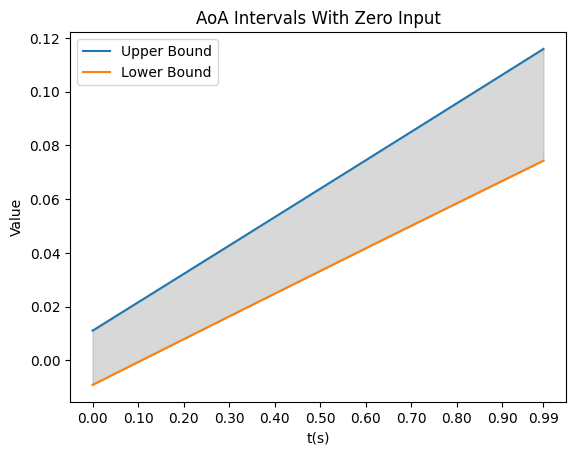

In [8]:

plt.plot(x_uppers_array[:, 1], label='Upper Bound')
plt.plot(x_lowers_array[:, 1], label='Lower Bound')
plt.fill_between(range(len(x_uppers_array)), x_lowers_array[:, 1], x_uppers_array[:, 1], color='gray', alpha=0.3)
plt.xlabel('t(s)')
plt.ylabel('Value')
# Show only a few evenly spaced ticks (e.g., every 10th tick), and add the final point t=1
step = 10
ticks = list(range(0, len(x_uppers_array), step))
if ticks[-1] != len(x_uppers_array) - 1:
    ticks.append(len(x_uppers_array) - 1)
labels = [f"{i/100:.2f}" for i in ticks]
plt.xticks(ticks=ticks, labels=labels)
plt.legend()
plt.title('AoA Intervals With Zero Input')
plt.show()

## 2. Calculate Optimal Open Loop Separating Input

In [8]:
def propagate_interval_euler_admire(x_ivl, u_ol, p_ivl, dt=0.01):
    return irx.ut2i(admire_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        u_ol,
        p_ivl,
    )) * dt + x_ivl

def loss_ff_jax(u_ol, x_interval, p_nominal, p_actuator_fault, dt, num_steps=10):
    """
    Loss function for the open-loop control input.
    This function is designed to be JIT-compiled.
    """
    # Propagate the initial state through the system dynamics
    def nominal_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_nominal, dt=dt)
    def actuator_fault_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_actuator_fault, dt=dt)
    x_ivl_nominal = jax.lax.fori_loop(0, num_steps, nominal_step_fn, x_interval)
    x_ivl_actuator_fault = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    # Calculate the loss as the squared difference between the propagated state and the observer offset
    loss = overlap_size_lax(
        x_ivl_nominal, x_ivl_actuator_fault
    )
    
    return loss

def loss_ff_three_jax(u_ol, x_interval, p_nominal, p_fault1, p_fault2, dt, num_steps=10):
    """
    Loss function for the open-loop control input.
    This function is designed to be JIT-compiled.
    """
    # Propagate the initial state through the system dynamics
    def nominal_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_nominal, dt=dt)
    def actuator_fault_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_fault1, dt=dt)
    def fault2_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_fault2, dt=dt)
    x_ivl_nominal = jax.lax.fori_loop(0, num_steps, nominal_step_fn, x_interval)
    x_ivl_fault1 = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    x_ivl_fault2 = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    # Calculate the loss as the squared difference between the propagated state and the observer offset
    loss = overlap_size_lax(x_ivl_nominal, x_ivl_fault1) + overlap_size_lax(x_ivl_nominal, x_ivl_fault2) + overlap_size_lax(x_ivl_fault1, x_ivl_fault2)
    return loss

def loss_ff_slow(u_ol, x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    x_ivl_nominal = x_interval
    x_ivl_actuator_fault = x_interval
    for i in range(num_steps):
        x_ivl_nominal = propagate_interval_euler_admire(x_ivl_nominal, u_ol, p_nominal, dt=dt)
        x_ivl_actuator_fault = propagate_interval_euler_admire(x_ivl_actuator_fault, u_ol, p_actuator_fault, dt=dt)
    return overlap_size(x_ivl_nominal, x_ivl_actuator_fault)

In [9]:
loss_grad = jax.grad(loss_ff_jax, argnums=0)
loss_3_grad = jax.grad(loss_ff_three_jax, argnums=0)
loss_slow = jax.grad(loss_ff_slow, argnums=0)
from jaxopt import LBFGSB
def calculate_optimal_open_loop_u(x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    """
    Calculates the optimal open-loop control input `u` using a multi-start gradient descent.
    This entire function is designed to be JIT-compiled.
    """
    # This inner function performs one run of gradient descent from a random starting point.
    def find_optimal_u():
        learning_rate = 1e2
        num_gd_steps = 10

        u_initial = jnp.ones(admire.ulen) * 1e-2

        # # Define the body of the gradient descent loop
        def gradient_step(i, u_current):
            grad = loss_grad(u_current, x_interval, p_nominal, p_actuator_fault, dt, num_steps=num_steps)
            print(f"grad value: {grad}")
            return u_current - learning_rate * grad
        

        u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)
    
        return u_opt#u_initial#u_opt


    return find_optimal_u()#batch_of_u_opts[best_run_index]

def calculate_optimal_open_loop_3_faults(x_interval, learning_rate, u_initial, p_nominal, p_fault1, p_fault2, dt, num_steps=100):
    num_gd_steps = 10
    # # Define the body of the gradient descent loop
    def gradient_step(i, u_current):
        grad = loss_3_grad(u_current, x_interval, p_nominal, p_fault1, p_fault2, dt, num_steps=num_steps)
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt#u_initial#u_opt



def calculate_optimal_open_loop_u_slow(x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    """
    Calculates the optimal open-loop control input `u` using a multi-start gradient descent.
    This entire function is designed to be JIT-compiled.
    """
    # This inner function performs one run of gradient descent from a random starting point.
    u_current = jnp.ones(admire.ulen) * 1e-2
    learning_rate = 1e1
    for i in range(10):
        grad = loss_slow(u_current, x_interval, p_nominal, p_actuator_fault, dt, num_steps=num_steps)
        print(f"grad value: {grad}")
        u_current -= learning_rate * grad
    return u_current

JIT u optimization

In [42]:
jit_calculate_optimal_open_loop_u = jit(partial(
    calculate_optimal_open_loop_u,
    p_nominal=p_nominal_ivl,
    p_actuator_fault=p_yaw_tv_ivl,
    dt=dt,
    num_steps=num_steps
))

In [69]:
jit_calculate_optimal_open_loop_u_3faults = jit(partial(
    calculate_optimal_open_loop_3_faults,
    p_nominal=p_nominal_ivl,
    p_fault1=p_yaw_tv_ivl,
    p_fault2=p_rudder_ivl,
    dt=dt,
    num_steps=num_steps
))

In [58]:
jax.block_until_ready(jit_calculate_optimal_open_loop_u(x0_interval_admire))

Array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],      dtype=float32)

In [70]:
jax.block_until_ready(
    jit_calculate_optimal_open_loop_u_3faults(
        x0_interval_admire, 
        1e8,
        jnp.array([0., 0., 0., 0., 0., 0., 0.01, 0., 0.01, 0.])
        )
        )

Array([-1.3950069e-03,  8.6548354e-04,  1.4616566e-03,  8.6368062e-04,
        1.3072388e-06, -9.4202574e-04,  4.4907294e-03,  7.8712765e-06,
        9.9999998e-03,  2.8550818e-03], dtype=float32)

In [56]:
%timeit u = jit_calculate_optimal_open_loop_u(x0_interval_admire)

485 ms ± 612 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [92]:
u = jit_calculate_optimal_open_loop_u_3faults(
    x0_interval_admire, 
    1e8, 
    jnp.ones(admire.ulen) * 0.01
    # jnp.array([0., 0., 0., 0., 0., 0., 0.1, 0., 0.01, 0.])
)
print(u)
print(loss_ff_three_jax(u, x0_interval_admire, p_nominal_ivl, p_yaw_tv_ivl, p_rudder_ivl, dt=0.1, num_steps=10))

[0.00919045 0.01137662 0.0110002  0.0101599  0.00927584 0.00862471
 0.00467549 0.00999152 0.01       0.00744392]
8.795096e-13


In [ ]:
total_t = 0.0
for _ in range(100):
    t0 = time.time()
    u = jit_calculate_optimal_open_loop_u(x0_interval_admire)
    t1 = time.time()
    total_t += t1 - t0
print(f"Average runtime: {total_t / 100:.4f}s")

Average runtime: 0.4769s


In [106]:
u = jit_calculate_optimal_open_loop_u(x0_interval_admire)

In [48]:
print(u)

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


In [48]:
loss_ff_three_jax(u_ol=u, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_fault1=p_yaw_tv_ivl, p_fault2=p_rudder_ivl, dt=.1)

Array(8.738342e-13, dtype=float32, weak_type=True)

In [50]:
loss_ff_jax(u_ol=jnp.ones(admire.ulen) * 1e-2, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_actuator_fault=p_yaw_tv_ivl, dt=.1)

Array(0., dtype=float32, weak_type=True)

In [25]:
loss_ff_slow(u_ol=jnp.ones(admire.ulen) * 1e-2, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_actuator_fault=p_yaw_tv_ivl, dt=.1)

[-1.05202119e+04            -inf            -inf -9.52692106e-02
 -9.06536341e-01 -1.23516284e-01            -inf -4.74900055e+00
            -inf]
[ 5.4849400e+05            inf            inf  4.5427904e-01
 -6.8803322e-01  3.3771738e-01            inf  2.1567526e+00
            inf]


Array(inf, dtype=float32)

### 2.1.2 Plots of embsys trajectory and embsys.F under Input

It was noticed that applying u=ones(10) * 0.01 will cause speed, AoA and Sideslip angles to blow up. To investigate what is happening, some plots are being produced.

In [55]:
# Modification of propagate_interval_euler to visualize embsys upper and lower on sys's dynamics.
import copy
def plot_intervals_euler_admire(u_ol, x_interval, p_nominal, p_actuator_fault, p_fault2=None, dt=0.1, num_steps=100):
    """
    Propagates two interval scenarios (nominal and fault) using Euler's method,
    stores the history of state and derivative intervals, and plots the results.

    This function breaks down the propagation step to explicitly capture the
    derivatives calculated by `admire_embsys.f`. It then plots the evolution
    of both state and derivative intervals for each of the 9 dimensions.

    Args:
        u_ol: Open-loop control input.
        x_interval (immrax.Interval): Initial interval for the state vector (9-dim).
        p_nominal (jnp.array): Nominal parameter set.
        p_actuator_fault (jnp.array): Faulty parameter set.
        dt (float): Time step for the Euler integration.
        num_steps (int): The number of steps to simulate.

    Returns:
        dict: A dictionary containing the lists of historical intervals for
              both scenarios. Keys are: "nominal_states", "fault_states",
              "nominal_derivatives", "fault_derivatives".
    """
    # Initialize state variables
    x_ivl_nominal = x_interval
    x_ivl_fault = x_interval

    # Lists to store the history of intervals
    nominal_state_history = [x_ivl_nominal]
    fault_state_history = [x_ivl_fault]
    if p_fault2 is not None:
        x_ivl_fault2 = copy.deepcopy(x_interval)
        fault2_state_history = [x_ivl_fault2]
        fault2_derivative_history = []
    nominal_derivative_history = []
    fault_derivative_history = []
    
    print(f"Starting simulation for {num_steps} steps...")

    # Main simulation loop
    for i in range(num_steps):
        # --- 1. Nominal Scenario Propagation ---
        
        # a. Calculate derivatives in upper-triangular form
        derivatives_nominal_ut = admire_embsys.f(0, irx.i2ut(x_ivl_nominal), u_ol, p_nominal)
        # b. Convert derivatives to an interval and save it
        derivative_ivl_nominal = irx.ut2i(derivatives_nominal_ut)
        nominal_derivative_history.append(derivative_ivl_nominal)
        # c. Apply Euler step and save the new state interval
        x_ivl_nominal = (derivative_ivl_nominal * dt) + x_ivl_nominal
        nominal_state_history.append(x_ivl_nominal)

        # --- 2. Actuator Fault Scenario Propagation ---
        # NOTE: Following the original logic, the "fault" state is propagated
        # with the "nominal" parameters.

        # a. Calculate derivatives in upper-triangular form
        derivatives_fault_ut = admire_embsys.f(0, irx.i2ut(x_ivl_fault), u_ol, p_actuator_fault)
        # b. Convert derivatives to an interval and save it
        derivative_ivl_fault = irx.ut2i(derivatives_fault_ut)
        fault_derivative_history.append(derivative_ivl_fault)
        # c. Apply Euler step and save the new state interval
        x_ivl_fault = (derivative_ivl_fault * dt) + x_ivl_fault
        fault_state_history.append(x_ivl_fault)

        if p_fault2 is not None:
            # a. Calculate derivatives in upper-triangular form
            derivatives_fault2_ut = admire_embsys.f(0, irx.i2ut(x_ivl_fault2), u_ol, p_fault2)
            # b. Convert derivatives to an interval and save it
            derivative_ivl_fault2 = irx.ut2i(derivatives_fault2_ut)
            fault2_derivative_history.append(derivative_ivl_fault2)
            # c. Apply Euler step and save the new state interval
            x_ivl_fault2 = (derivative_ivl_fault2 * dt) + x_ivl_fault2
            fault2_state_history.append(x_ivl_fault2)

    print("Simulation finished. Preparing data for plotting...")

    # --- Data Preparation for Plotting ---
    # Create time axes
    time_axis_states = jnp.arange(num_steps + 1) * dt  # For states (t=0 to t_final)
    time_axis_derivs = jnp.arange(num_steps) * dt      # For derivatives (t=0 to t_final-dt)

    # Stack interval histories into JAX arrays for efficient indexing
    # Shape: (num_steps, 9)
    nominal_derivs_lower = jnp.stack([ivl.lower for ivl in nominal_derivative_history])
    nominal_derivs_upper = jnp.stack([ivl.upper for ivl in nominal_derivative_history])
    fault_derivs_lower = jnp.stack([ivl.lower for ivl in fault_derivative_history])
    fault_derivs_upper = jnp.stack([ivl.upper for ivl in fault_derivative_history])
    
    # Shape: (num_steps + 1, 9)
    nominal_states_lower = jnp.stack([ivl.lower for ivl in nominal_state_history])
    nominal_states_upper = jnp.stack([ivl.upper for ivl in nominal_state_history])
    fault_states_lower = jnp.stack([ivl.lower for ivl in fault_state_history])
    fault_states_upper = jnp.stack([ivl.upper for ivl in fault_state_history])

    if p_fault2 is not None:
        fault2_derivs_lower = jnp.stack([ivl.lower for ivl in fault2_derivative_history])
        fault2_derivs_upper = jnp.stack([ivl.upper for ivl in fault2_derivative_history]) 
        fault2_states_lower = jnp.stack([ivl.lower for ivl in fault2_state_history])
        fault2_states_upper = jnp.stack([ivl.upper for ivl in fault2_state_history])

    print("Generating plots...")
    # --- Plotting ---
    num_dims = x_interval.lower.shape[0]
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    for dim in range(num_dims):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # Plot 1: Derivatives
        ax1.set_title("Derivative Intervals (dx/dt)")
        ax1.plot(time_axis_derivs, nominal_derivs_lower[:, dim], color='blue', ls='-', label='Nominal Lower')
        ax1.plot(time_axis_derivs, nominal_derivs_upper[:, dim], color='blue', ls='-')
        ax1.fill_between(time_axis_derivs, nominal_derivs_lower[:, dim], nominal_derivs_upper[:, dim], 
                         color='blue', alpha=0.2, label='Nominal Interval')

        ax1.plot(time_axis_derivs, fault_derivs_lower[:, dim], color='red', ls='--', label='Fault Lower')
        ax1.plot(time_axis_derivs, fault_derivs_upper[:, dim], color='red', ls='--')
        ax1.fill_between(time_axis_derivs, fault_derivs_lower[:, dim], fault_derivs_upper[:, dim], 
                         color='red', alpha=0.2, label='Fault Interval')
        

        # Plot 2: Computed State Intervals
        ax2.set_title("State Intervals (x)")
        ax2.plot(time_axis_states, nominal_states_lower[:, dim], color='blue', ls='-')
        ax2.plot(time_axis_states, nominal_states_upper[:, dim], color='blue', ls='-')
        ax2.fill_between(time_axis_states, nominal_states_lower[:, dim], nominal_states_upper[:, dim], 
                         color='blue', alpha=0.2, label='Nominal Interval')

        ax2.plot(time_axis_states, fault_states_lower[:, dim], color='red', ls='--')
        ax2.plot(time_axis_states, fault_states_upper[:, dim], color='red', ls='--')
        ax2.fill_between(time_axis_states, fault_states_lower[:, dim], fault_states_upper[:, dim], 
                         color='red', alpha=0.2, label='Fault Interval')
        

        if p_fault2 is not None:
            ax1.plot(time_axis_derivs, fault2_derivs_lower[:, dim], color='yellow', ls='--', label='Fault Lower')
            ax1.plot(time_axis_derivs, fault2_derivs_upper[:, dim], color='yellow', ls='--')
            ax1.fill_between(time_axis_derivs, fault2_derivs_lower[:, dim], fault2_derivs_upper[:, dim], 
                            color='yellow', alpha=0.2, label='Fault Interval')
            ax2.plot(time_axis_states, fault2_states_lower[:, dim], color='yellow', ls='--')
            ax2.plot(time_axis_states, fault2_states_upper[:, dim], color='yellow', ls='--')
            ax2.fill_between(time_axis_states, fault2_states_lower[:, dim], fault2_states_upper[:, dim], 
                            color='yellow', alpha=0.2, label='Fault Interval')


        ax1.set_ylabel('Derivative Value')
        ax1.legend()
        ax1.grid(True, linestyle=':')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # Return the collected data
    return {
        "nominal_states": nominal_state_history,
        "fault_states": fault_state_history,
        "nominal_derivatives": nominal_derivative_history,
        "fault_derivatives": fault_derivative_history,
    }



### 2.2. Plot Reachable Sets Under Separating Inputs

Starting simulation for 10 steps...
Simulation finished. Preparing data for plotting...
Generating plots...


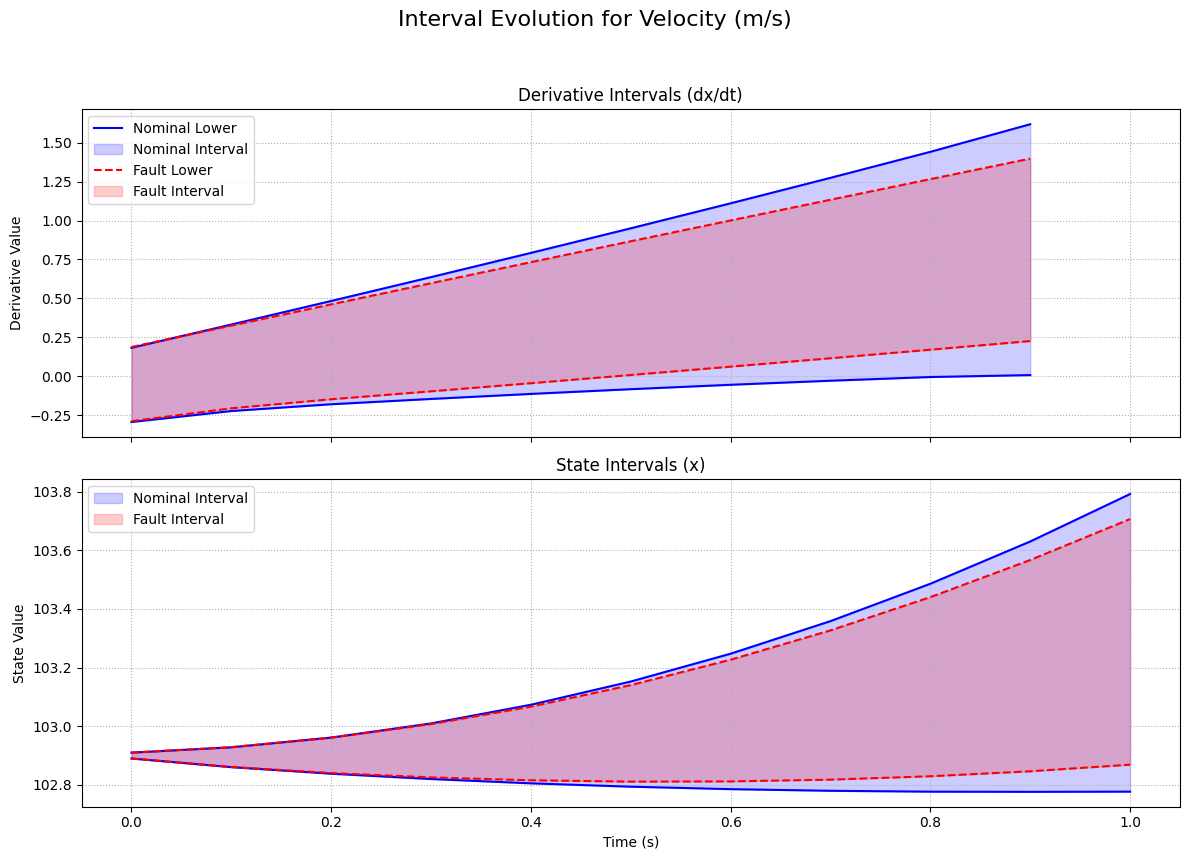

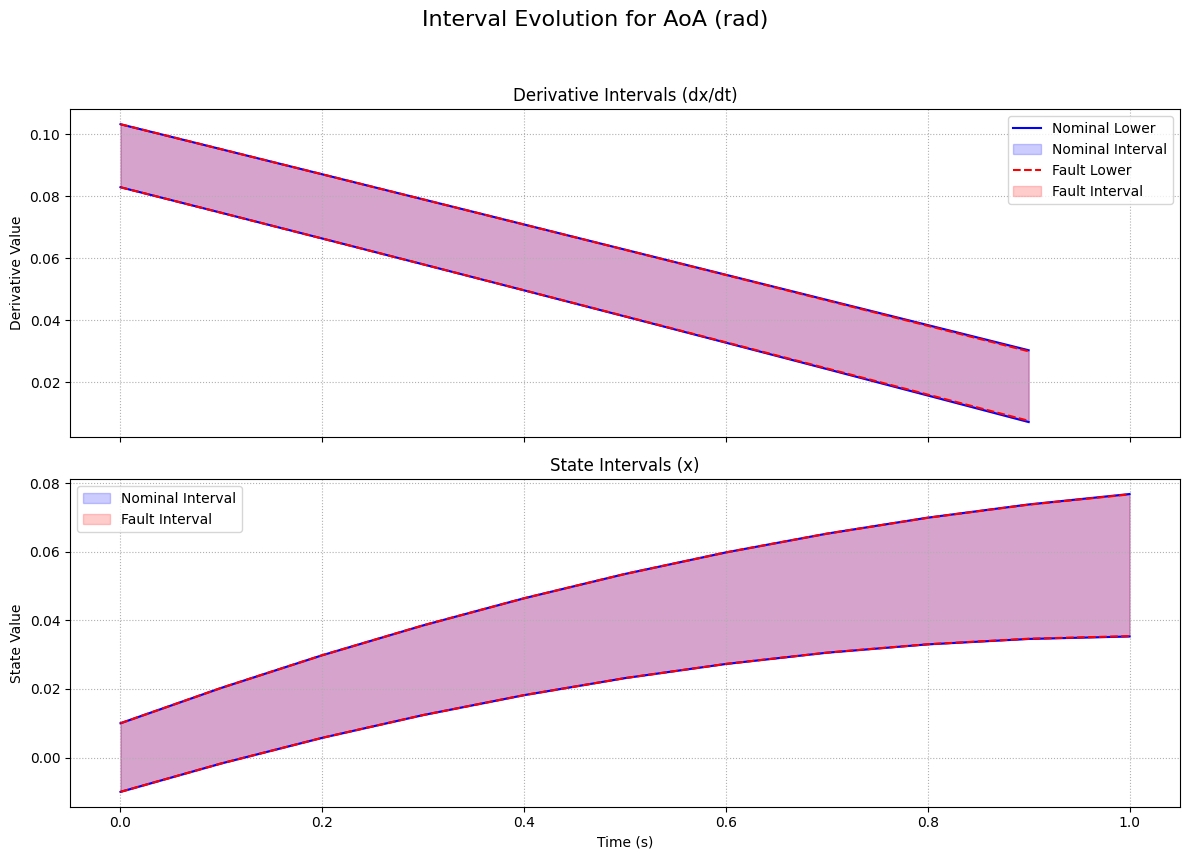

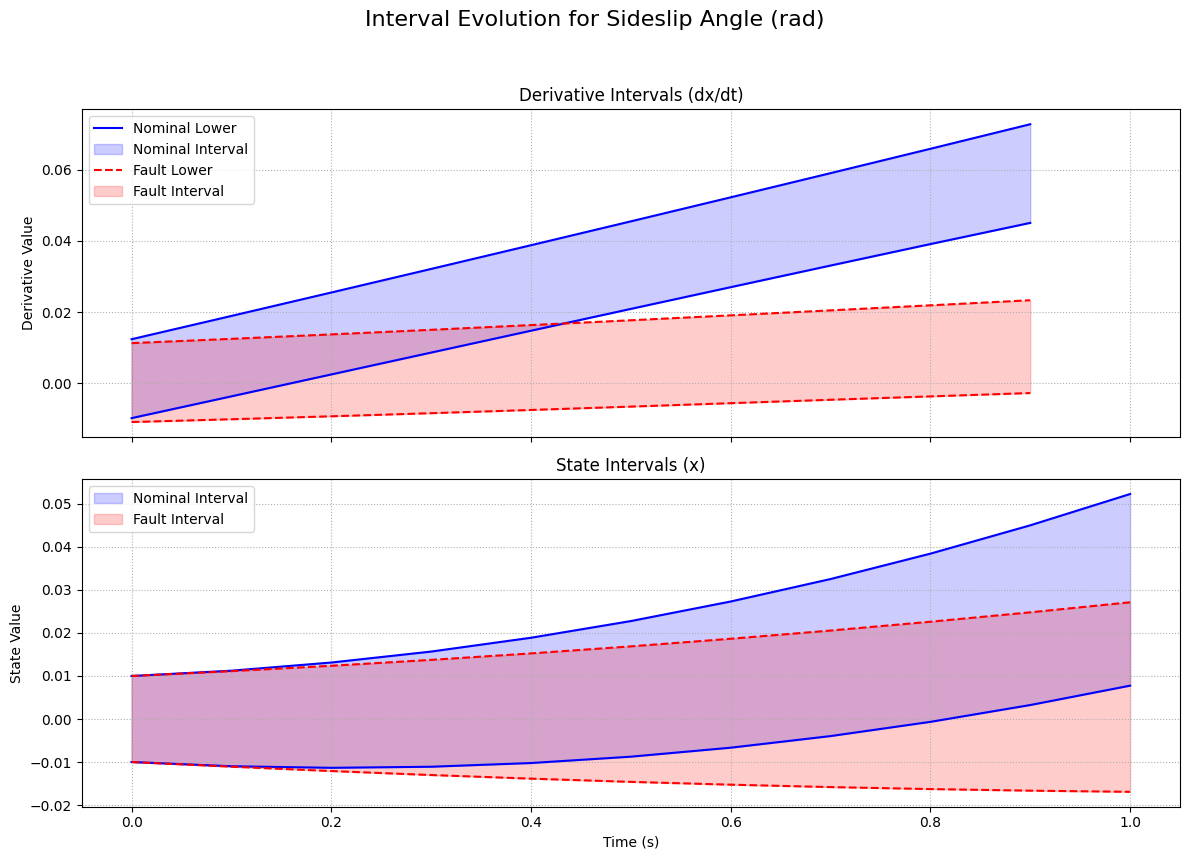

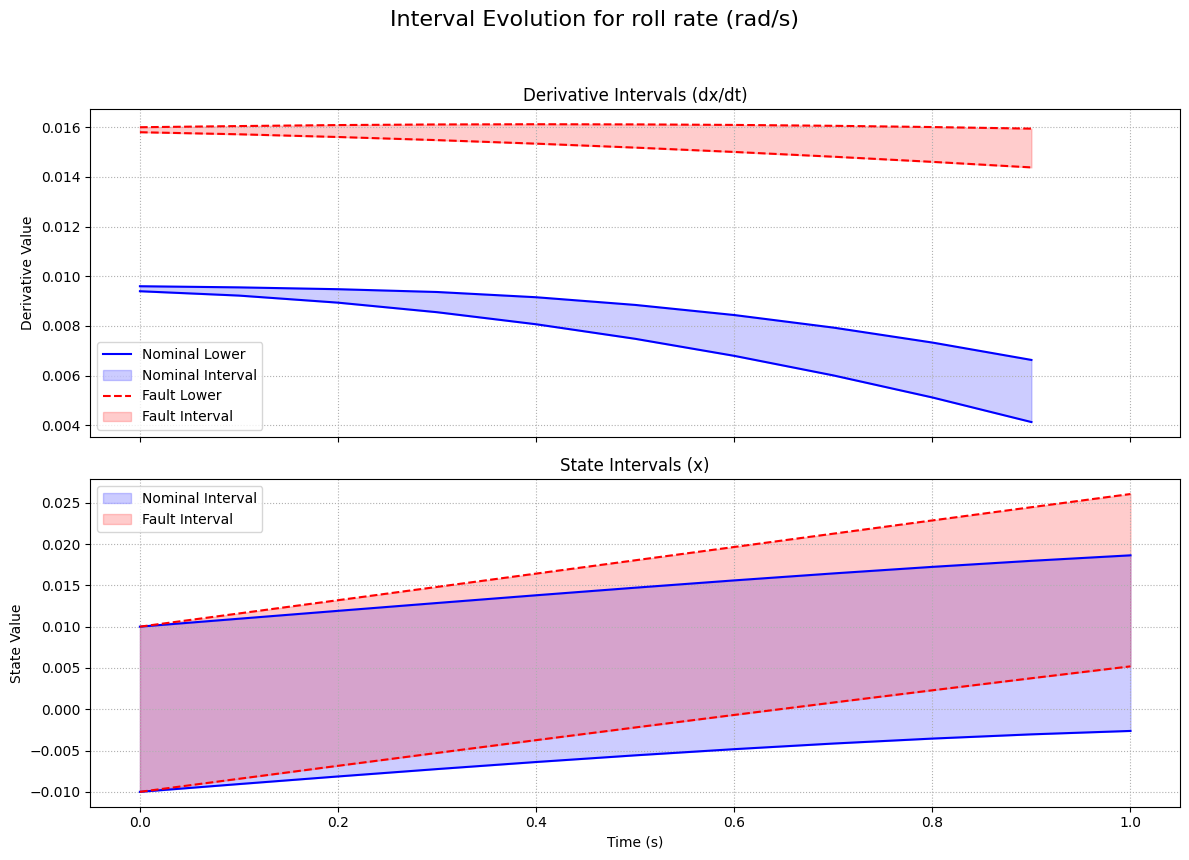

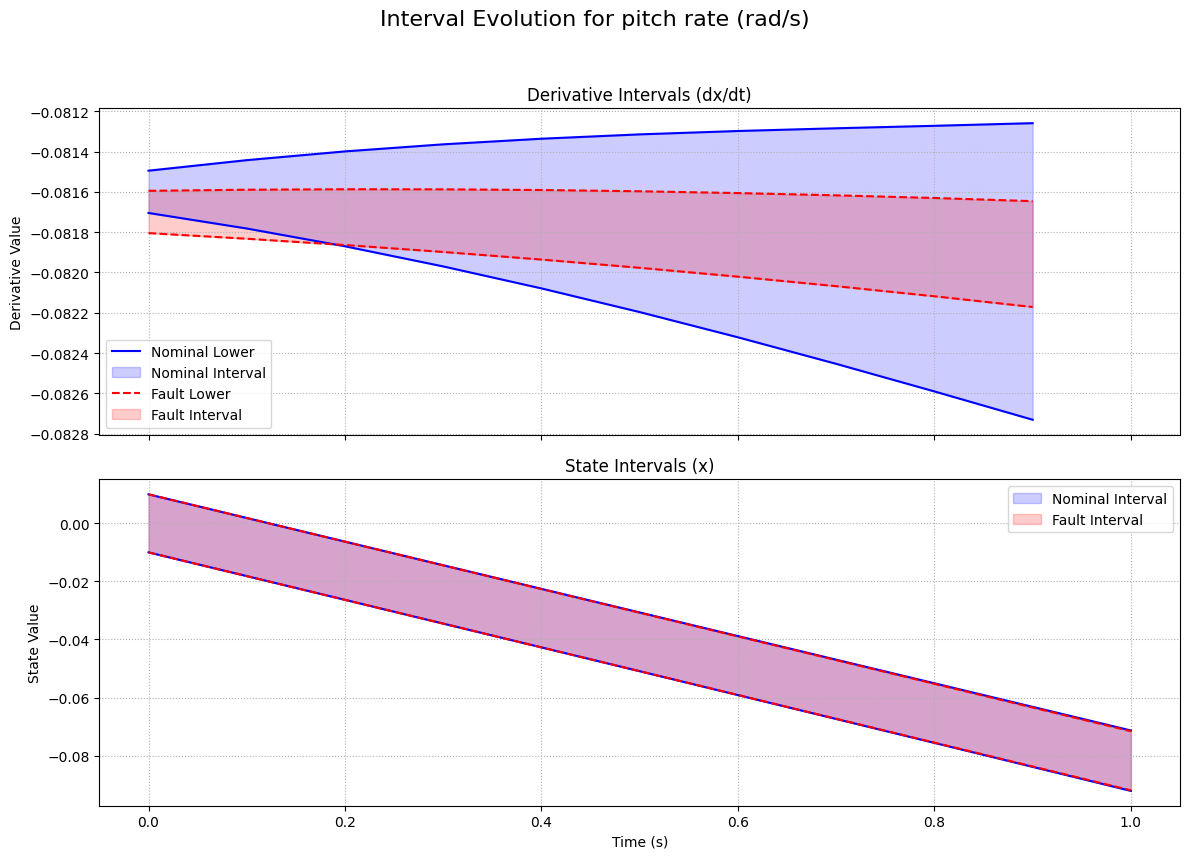

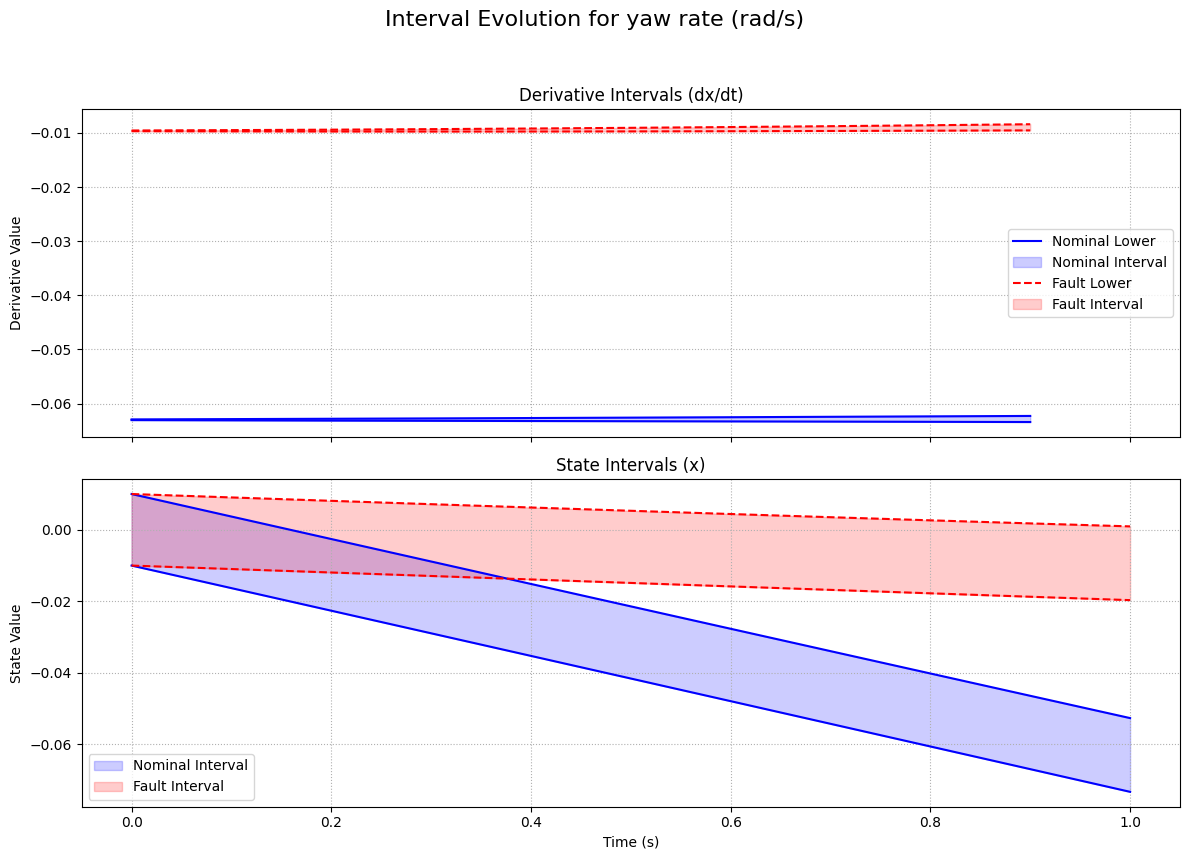

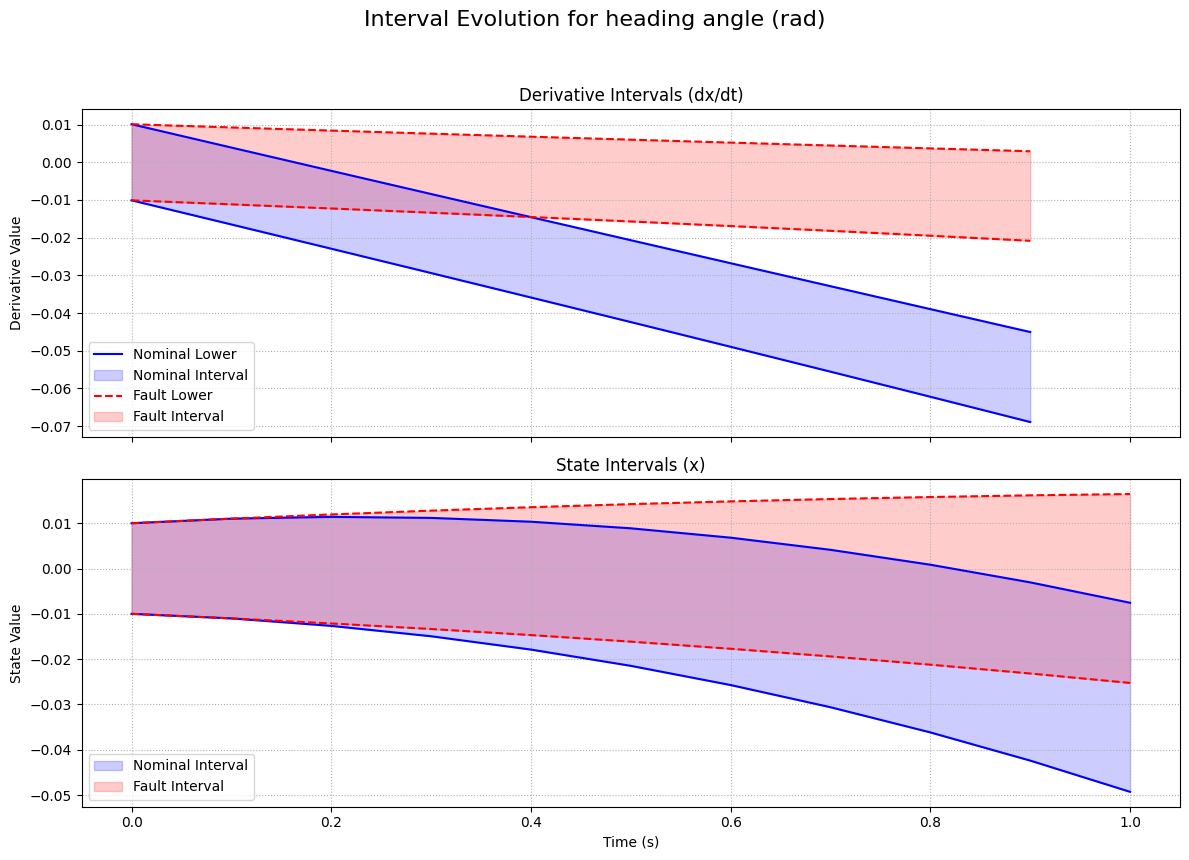

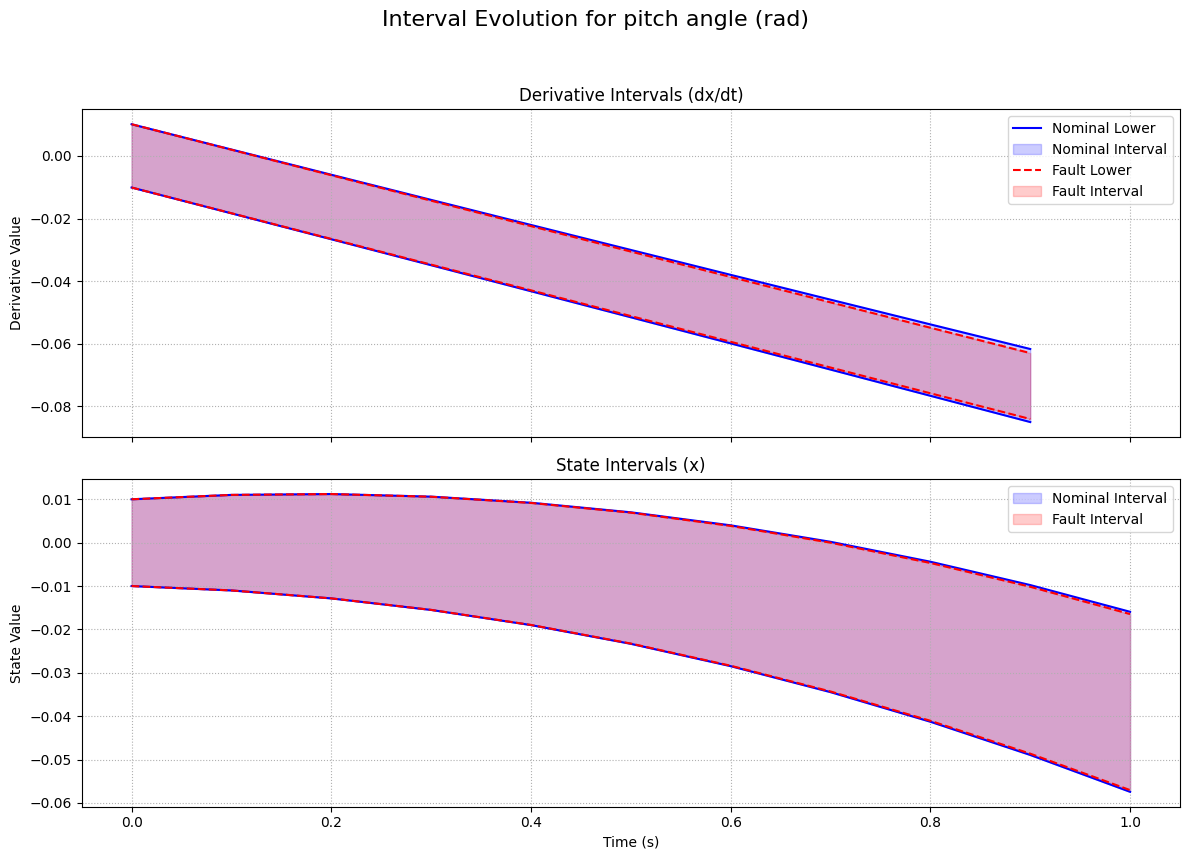

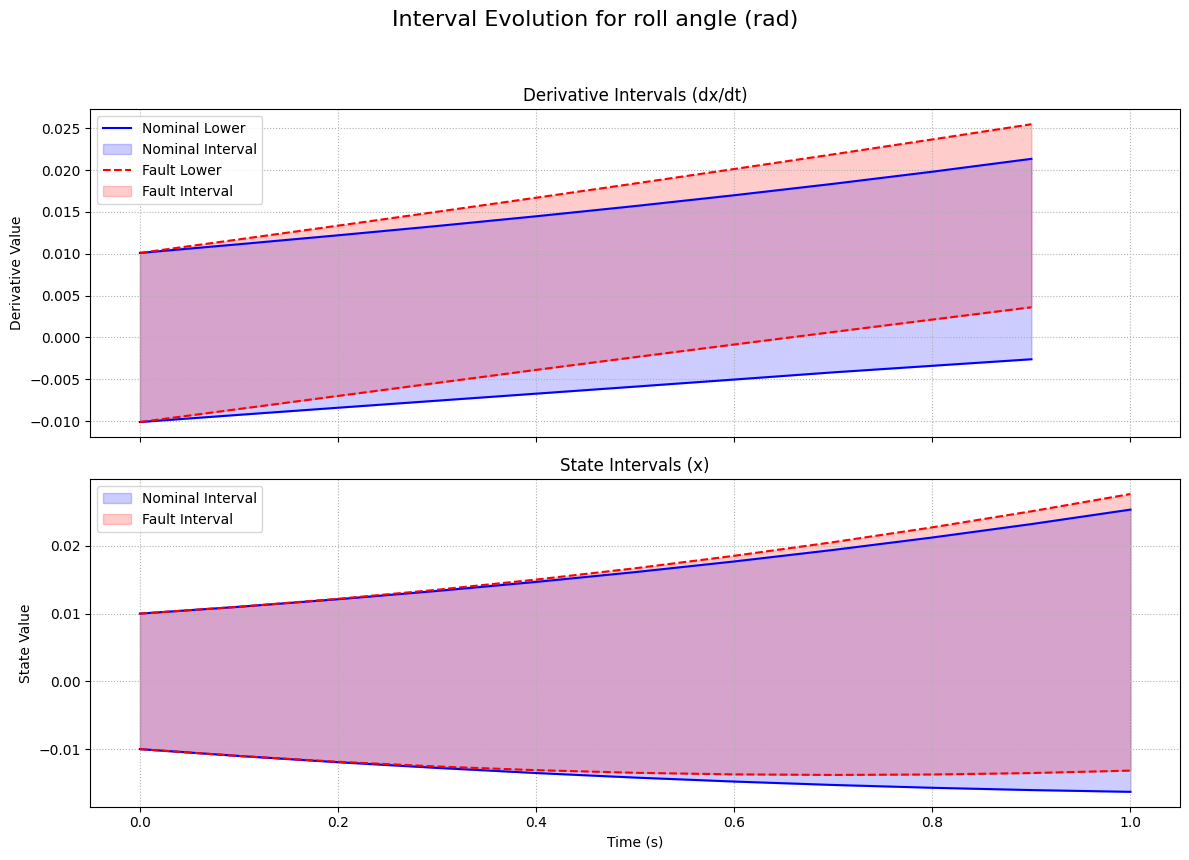

In [35]:
history_data = plot_intervals_euler_admire(
        u_ol=jnp.ones(admire.ulen) * 0.01,
        x_interval=x0_interval_admire,
        p_nominal=p_nominal_ivl,
        p_actuator_fault=p_yaw_tv_ivl,
        dt=0.1,
        num_steps=10
    )

Starting simulation for 10 steps...
Simulation finished. Preparing data for plotting...
Generating plots...


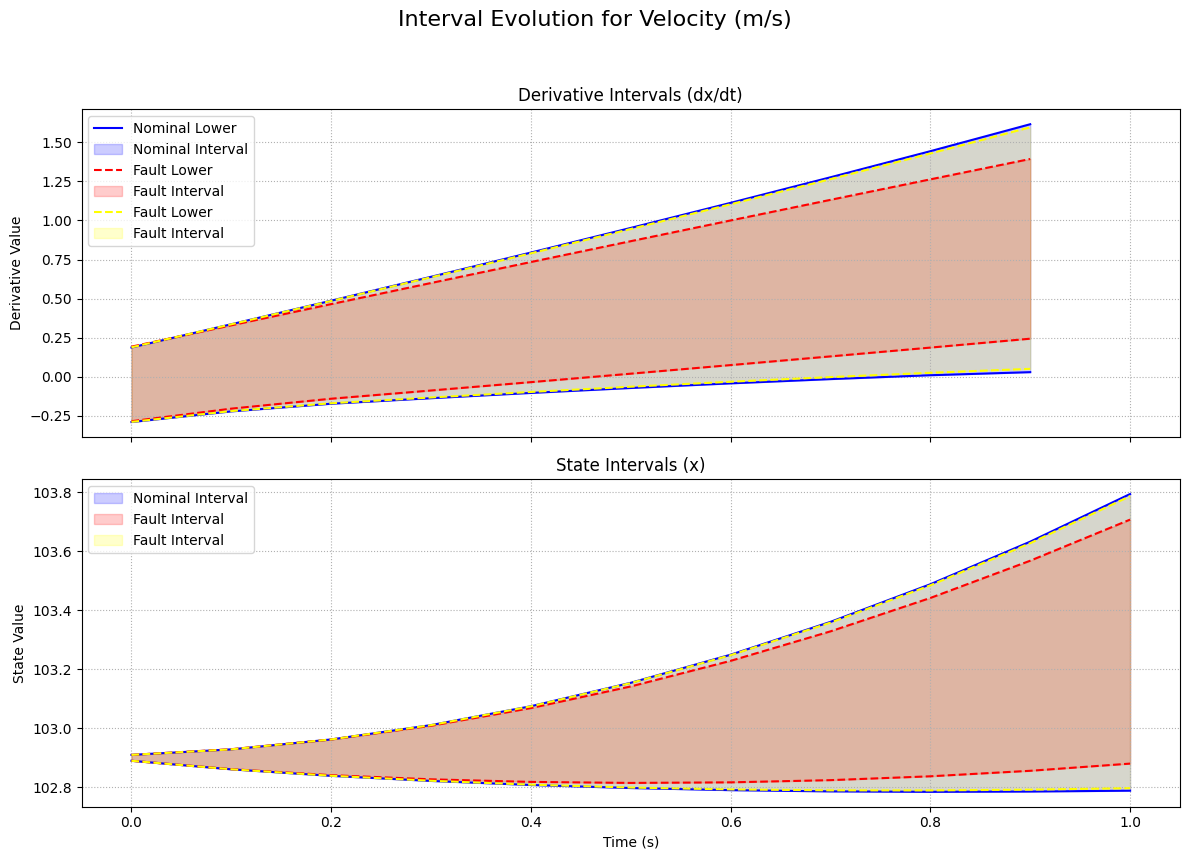

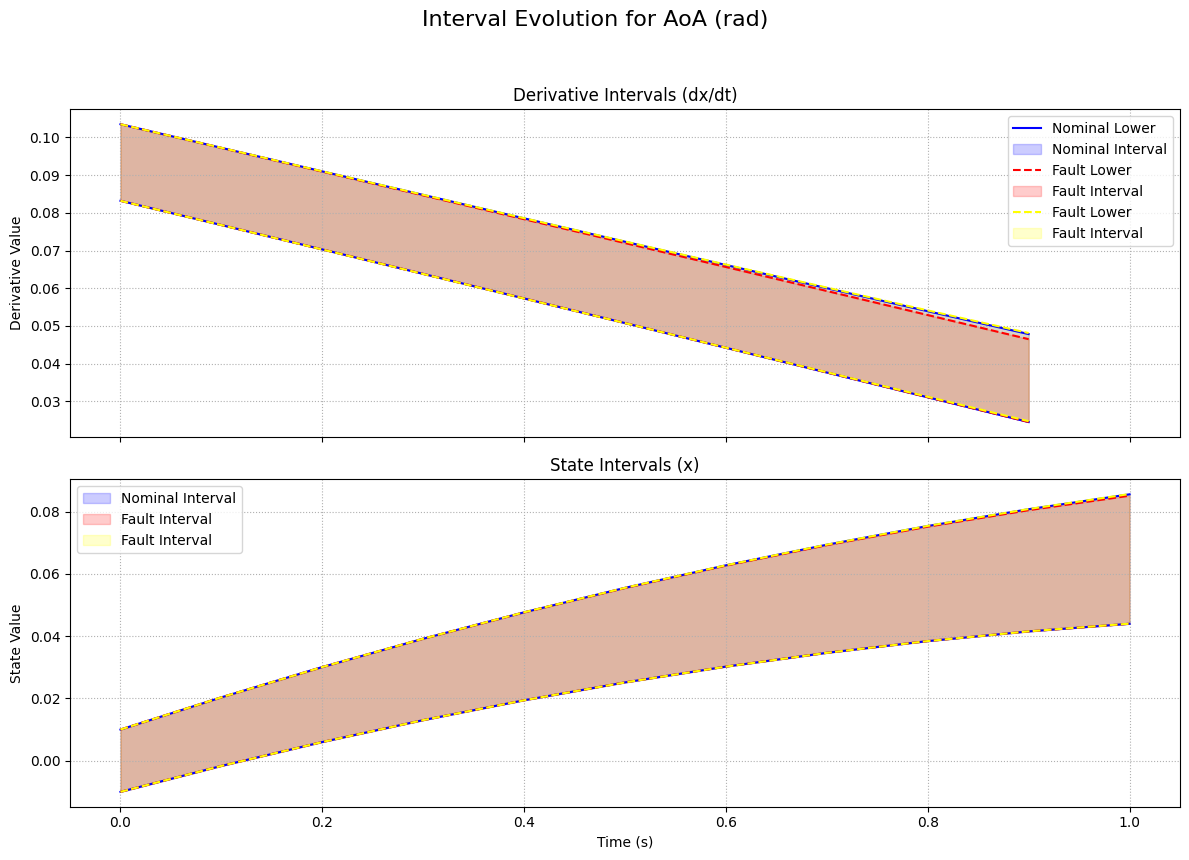

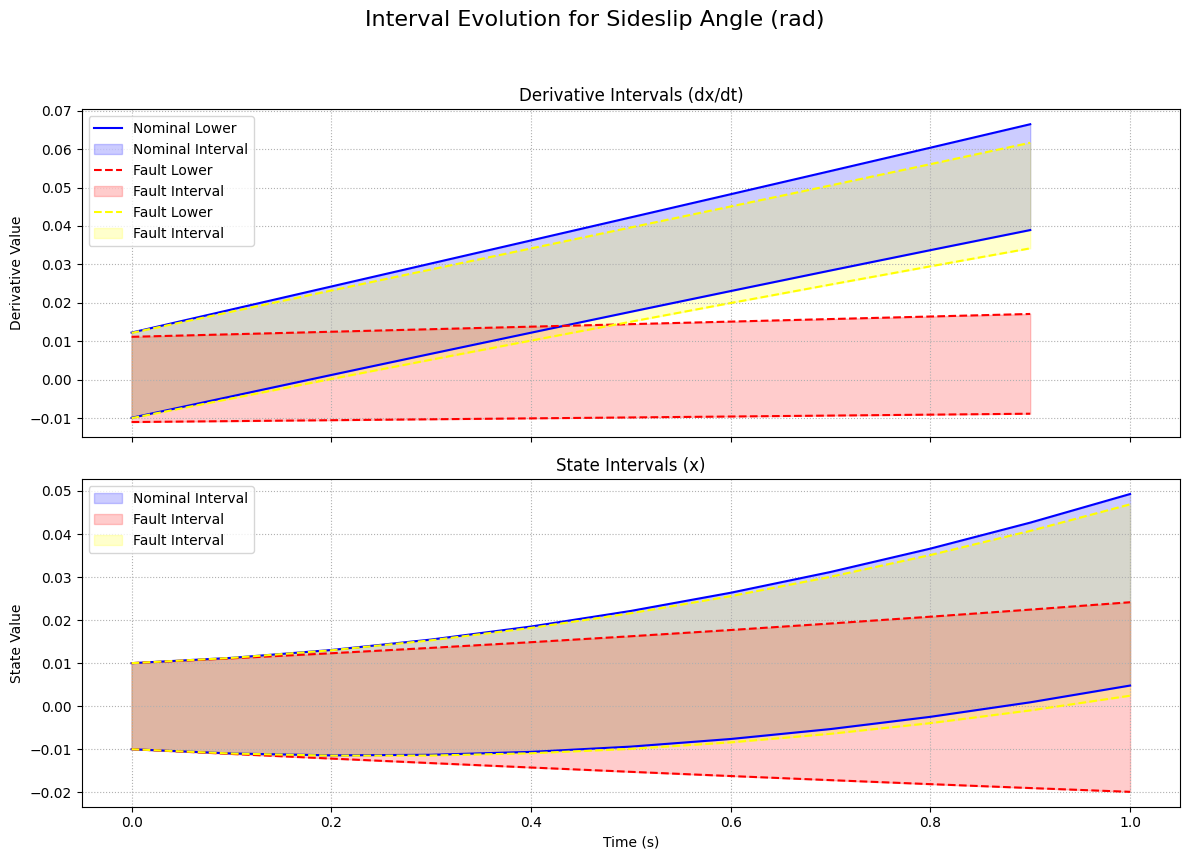

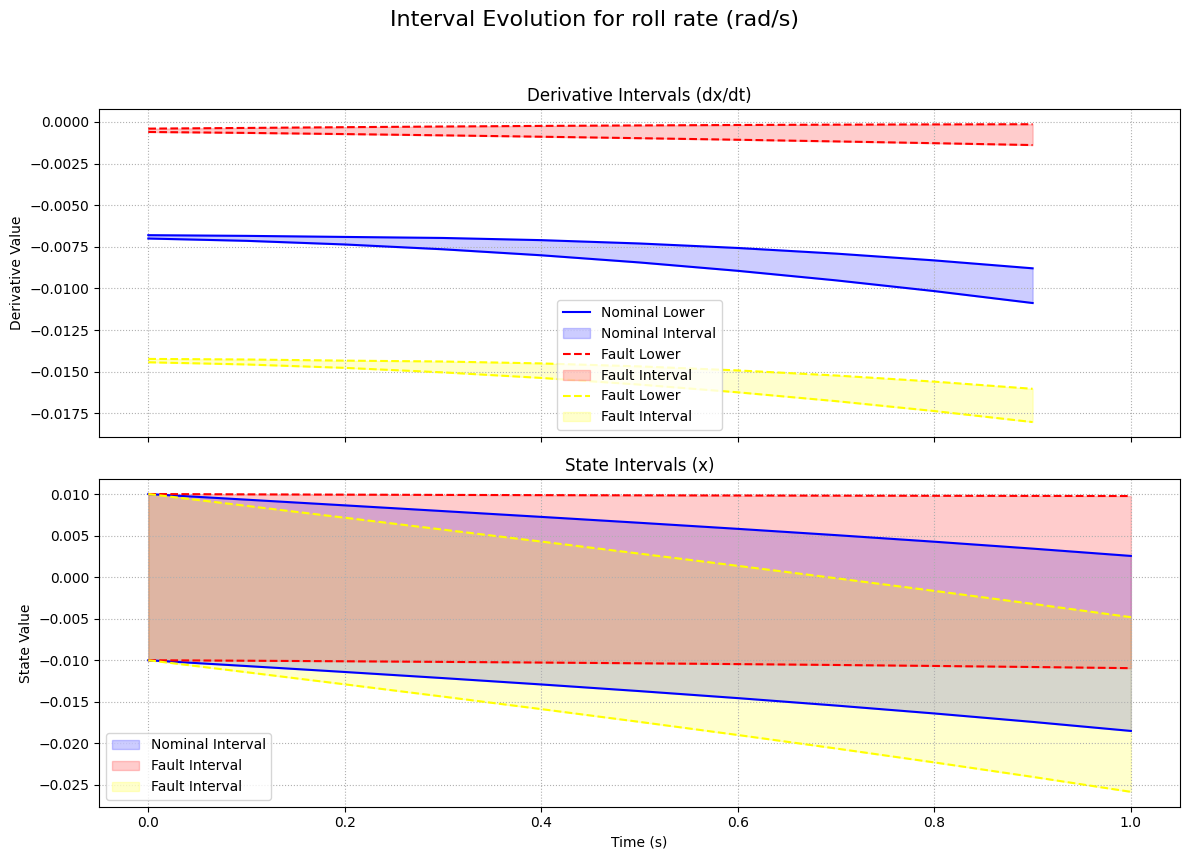

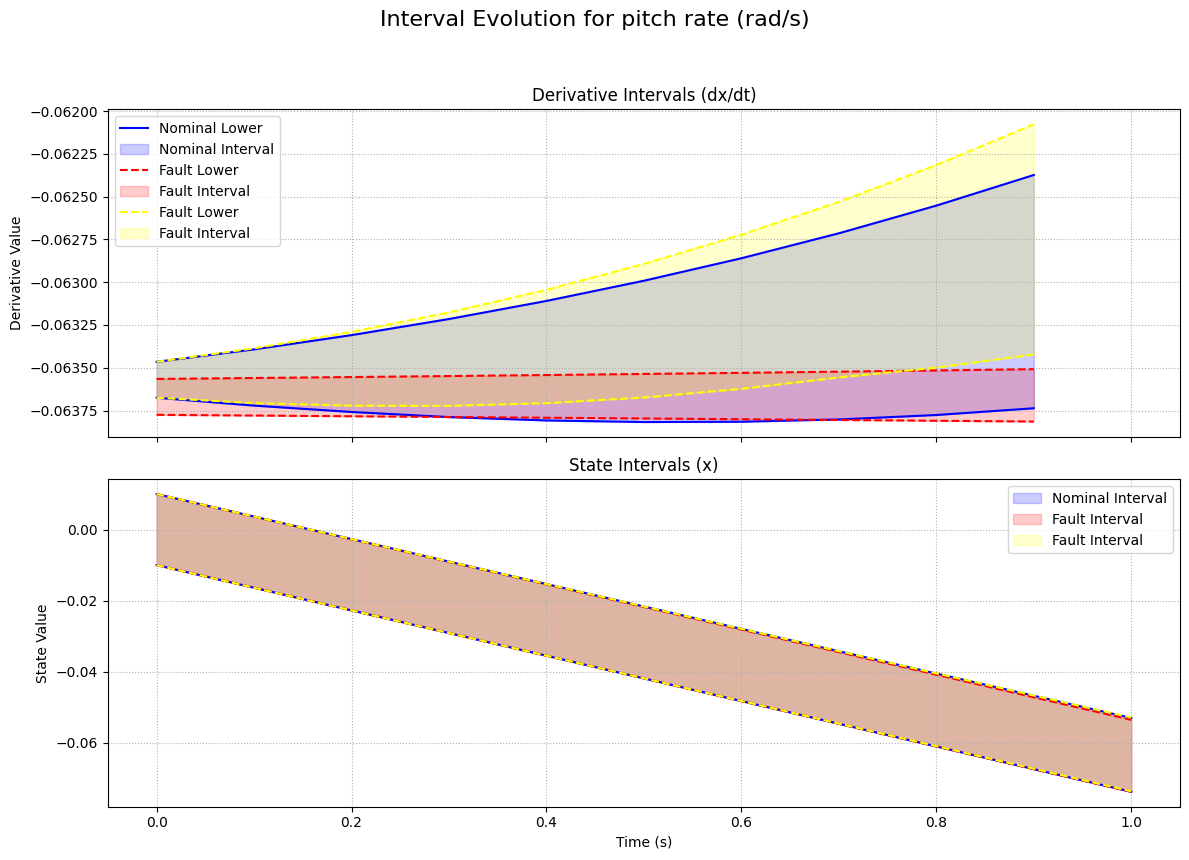

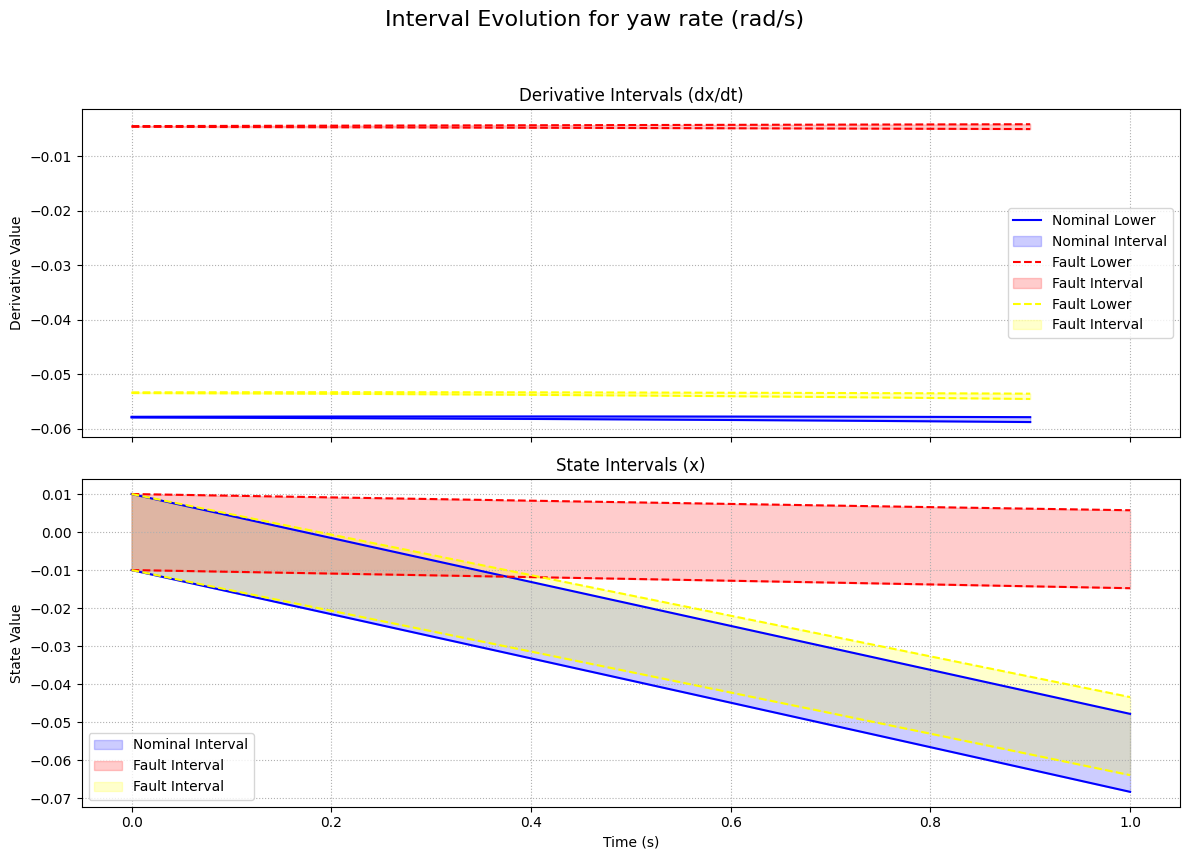

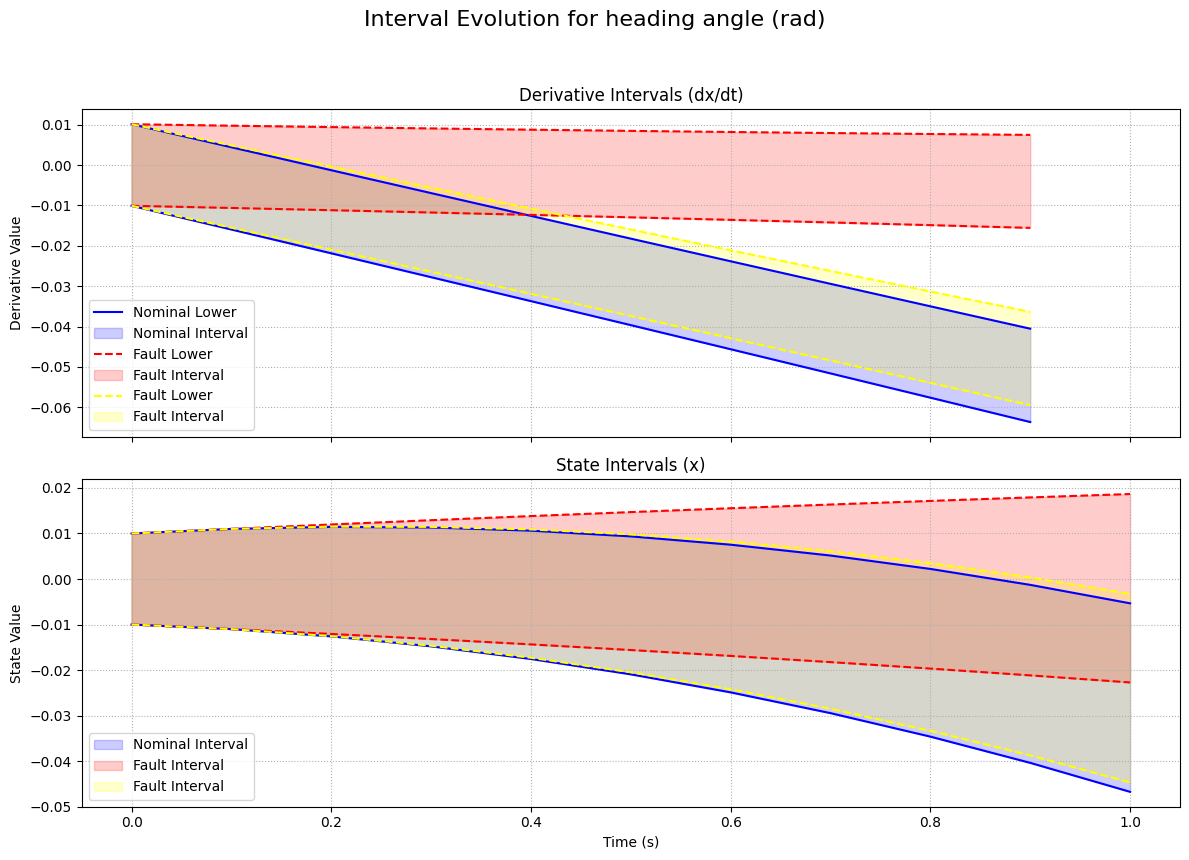

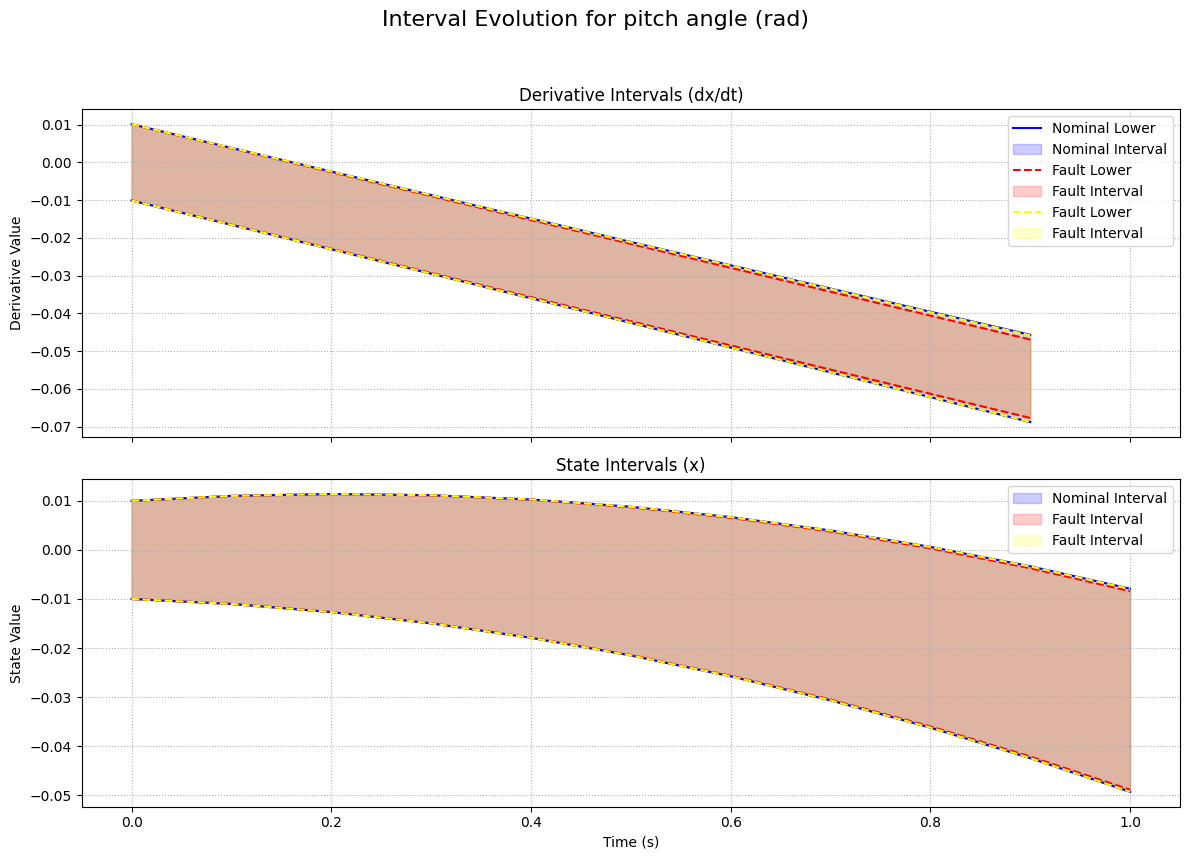

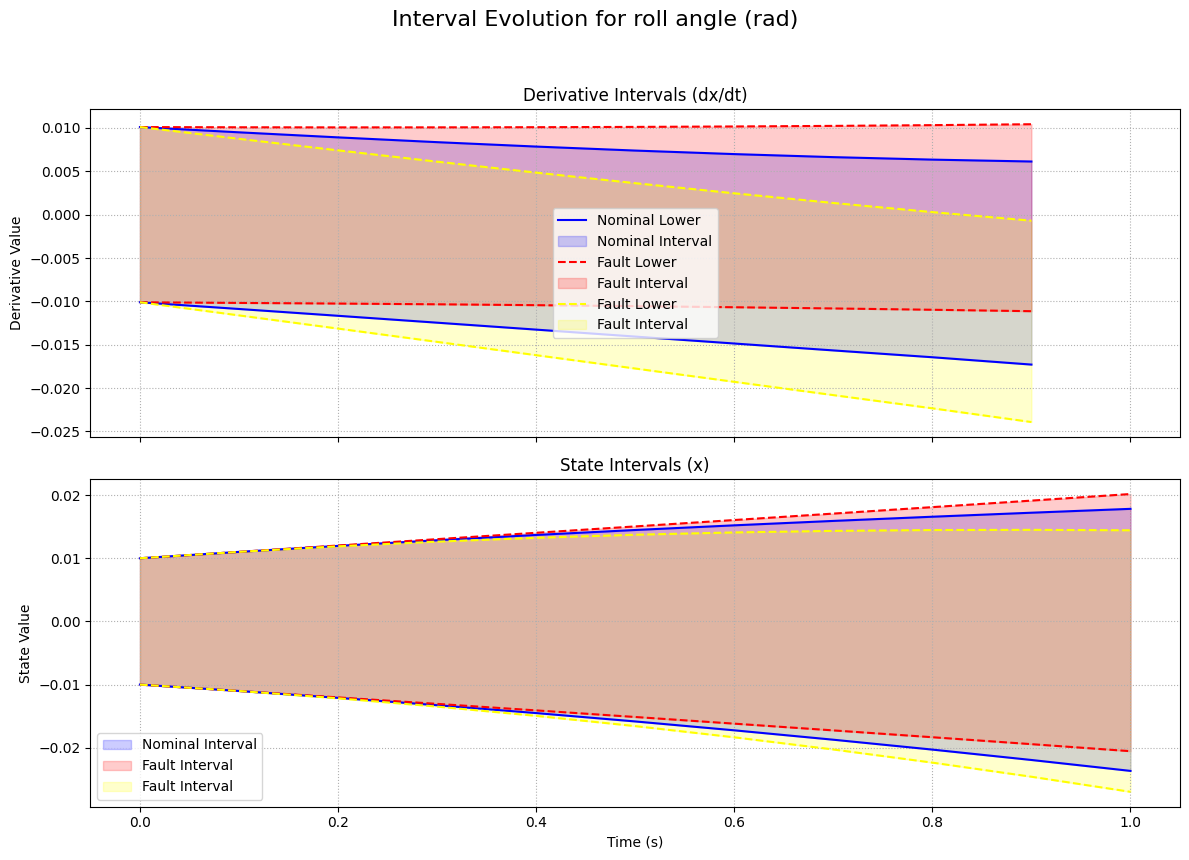

In [93]:
history_data_3faults = plot_intervals_euler_admire(
    u_ol = u,#jnp.array([0., 0., 0., 0., 0., 0., 0.01, 0., 0.001, 0.]),
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_actuator_fault=p_yaw_tv_ivl,
    p_fault2=p_rudder_ivl,
    dt=0.1,
    num_steps=10
)

## 3 Adding More Faults

### 3.1 Definition of general loss function for multiple faults

First, we need to revise our loss function to support multiple faults.

In [10]:
def loss_ff_generalized_scan_vmap_jax(u_ol, x_interval, p_nominal, p_faults, dt, num_sim_steps=10):
    # (This function is identical to the one in the previous answer)
    # 1. Propagate nominal case with scan
    def nominal_scan_fn(carry_x_ivl, _):
        next_x_ivl = propagate_interval_euler_admire(carry_x_ivl, u_ol, p_nominal, dt=dt)
        return next_x_ivl, None
    x_ivl_nominal, _ = jax.lax.scan(nominal_scan_fn, x_interval, None, length=num_sim_steps)

    # 2. Propagate all fault cases
    def propagate_single_fault(p_fault):
        def fault_scan_fn(carry_x_ivl, _):
            next_x_ivl = propagate_interval_euler_admire(carry_x_ivl, u_ol, p_fault, dt=dt)
            return next_x_ivl, None
        final_x_ivl, _ = jax.lax.scan(fault_scan_fn, x_interval, None, length=num_sim_steps)
        return final_x_ivl
    x_ivls_fault = jax.lax.map(propagate_single_fault, p_faults)

    # 3. Combine results
    all_ivls = jax.tree_util.tree_map(
        lambda n, f: jnp.concatenate([jnp.expand_dims(n, axis=0), f], axis=0),
        x_ivl_nominal, x_ivls_fault
    )

    # 4. Calculate pairwise loss with vmap
    num_faults = jax.tree_util.tree_leaves(p_faults)[0].shape[0]
    num_scenarios = 1 + num_faults
    i_indices, j_indices = jnp.triu_indices(num_scenarios, k=1)
    ivls_i = jax.tree_util.tree_map(lambda leaf: leaf[i_indices], all_ivls)
    ivls_j = jax.tree_util.tree_map(lambda leaf: leaf[j_indices], all_ivls)
    pairwise_losses = jax.vmap(overlap_sum_lax, in_axes=(0, 0))(ivls_i, ivls_j)
    
    return jnp.sum(pairwise_losses)

### 3.2 Optimization

We then need to find a good open-loop u.

In [9]:
import optax
grad_loss_f = jax.grad(loss_ff_generalized_scan_vmap_jax, argnums=0)
def find_optimal_open_loop_adam(
    x_interval: irx.Interval, 
    learning_rate: float, 
    u_initial: jnp.ndarray, 
    p_nominal: irx.Interval, 
    p_faults: List[irx.Interval],  # <-- Key change: Type is now List[Interval]
    dt: float, 
    num_sim_steps: int = 10, 
    num_gd_steps: int = 10
):
    """
    Finds the optimal open-loop control input 'u_ol' using the Adam optimizer.

    This version accepts a Python list of `immrax.Interval` objects for `p_faults`.
    """
    # ----------------------------------------------------------------------
    # KEY STEP: Convert the list of Pytrees into a single Pytree of stacks.
    # `jax.lax.map` and other transforms require a Pytree with a leading
    # batch dimension, not a Python list.
    if not p_faults:
        raise ValueError("The `p_faults` list cannot be empty.")

    # `*p_faults` unpacks the list into separate arguments for tree_map.
    # `lambda *leaves: jnp.stack(leaves)` takes corresponding leaves from each
    # tree (e.g., all 'lower' arrays) and stacks them into a single array.
    p_faults_stacked = jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults)
    # ----------------------------------------------------------------------
    
    # 1. Instantiate the Adam optimizer from optax
    optimizer = optax.adam(learning_rate)

    # 2. Create a function that calculates the gradient of our loss function.
    # The arguments to the loss function that are not being differentiated
    # are now "baked in" to this gradient function.
    def grad_loss_fn(u_ol_params):
        return jax.grad(loss_ff_generalized_scan_vmap_jax, argnums=0)(
            u_ol_params, x_interval, p_nominal, p_faults_stacked, dt, num_sim_steps
        )

    # 3. Initialize the optimizer state.
    params = u_initial
    opt_state = optimizer.init(params)
    
    # 4. Define the stateful gradient descent step function for the loop.
    def gradient_step(i, state):
        current_params, current_opt_state = state
        grads = grad_loss_fn(current_params)
        updates, new_opt_state = optimizer.update(grads, current_opt_state, current_params)
        new_params = optax.apply_updates(current_params, updates)
        return (new_params, new_opt_state)

    # 5. Run the optimization loop.
    initial_loop_state = (params, opt_state)
    final_params, _ = jax.lax.fori_loop(0, num_gd_steps, gradient_step, initial_loop_state)
    
    u_opt = final_params
    return u_opt

In [10]:
jax_grad_multiple = jax.grad(loss_ff_generalized_scan_vmap_jax, argnums=0)

def calculate_optimal_open_loop_multiple_faults(x_interval, learning_rate, u_initial, p_nominal, p_faults, dt, num_gd_steps=10, num_steps=100):
    # # Define the body of the gradient descent loop
    p_faults_stacked = jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults)
    def gradient_step(i, u_current):
        grad = jax_grad_multiple(u_current, x_interval, p_nominal, p_faults_stacked, dt, num_steps=num_steps)
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt#u_initial#u_opt

Define fault set here.

In [11]:
p_faults_list = [p_rc_ivl, p_lc_ivl, p_roe_ivl, p_rie_ivl, p_lie_ivl, p_loe_ivl, p_rudder_ivl, p_yaw_tv_ivl, p_pitch_tv_ivl]
fault_names = [
    "Right Canard Fault", 
    "Left Canard Fault", 
    "Right Outboard Elevon Fault",
    "Right Inboard Elevon Fault",
    "Left Inboard Elevon Fault",
    "Left Outboard Elevon Fault",
    "Rudder Fault",
    "Yaw Thrust Vectoring Fault", 
    "Pitch Thrust Vectoring Fault"
    ]

In [12]:
jit_calculate_optimal_open_loop_u_multiple_adam = jit(partial(
    find_optimal_open_loop_adam,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    dt=dt,
    num_sim_steps=num_steps
))

In [15]:
u = jax.block_until_ready(jit_calculate_optimal_open_loop_u_multiple_adam(
    x0_interval_admire,
    1e-2,
    jnp.ones(admire.ulen) * 0.01,
    # num_gd_steps=10
))

In [16]:
print(u)

[0.04055063 0.06158563 0.04228251 0.03371212 0.02060133 0.02893855
 0.02615117 0.00570083 0.00337841 0.01143281]


In [83]:
u = jit_calculate_optimal_open_loop_u_multiple_adam(
    x0_interval_admire,
    1e-1,
    jnp.ones(admire.ulen) * 0.01
)

In [33]:
u2 = jit_calculate_optimal_open_loop_u_multiple_adam(
    x0_interval_admire,
    1e-2,
    jnp.array([0., 0., 0., 0., 0., .1, .1, .1, .1, .1, .0]))

2025-08-04 09:23:08.413653: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__unnamed_wrapped_function_] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-08-04 09:23:33.151829: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m24.738260576s

********************************
[Compiling module jit__unnamed_wrapped_function_] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [93]:
print(u)
p_faults_stacked = jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults_list)
cost = loss_ff_generalized_scan_vmap_jax(
    u_ol=u * 10,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_stacked,
    dt=.1,
    num_sim_steps=10
    
)


[0.01445909 0.01875349 0.01900226 0.01011046 0.01096146 0.01993519
 0.01459736 0.00999447 0.00382745 0.00824308]


In [94]:
print(cost)

0.0


### 3.3 Plotting More Faults

In [49]:
def plot_intervals_generalized(
    u_ol: jnp.ndarray,
    x_interval: irx.Interval,
    p_nominal: irx.Interval,
    p_faults: List[irx.Interval],
    fault_names: List[str],
    fault_colors: Optional[List[str]] = None,
    dt: float = 0.1,
    num_steps: int = 100
) -> Dict[str, Any]:
    """
    Propagates and plots the interval evolution for a nominal scenario and an
    arbitrary number of fault scenarios.

    Args:
        u_ol: Open-loop control input.
        x_interval: Initial interval for the state vector.
        p_nominal: Nominal parameter set as an Interval.
        p_faults: A list of parameter Intervals, one for each fault scenario.
        fault_names: A list of strings with names for each fault scenario.
        fault_colors: (Optional) A list of color strings for faults. If None,
                      colors are generated automatically.
        dt: Time step for Euler integration.
        num_steps: The number of steps to simulate.

    Returns:
        A dictionary containing the history of states and derivatives for all scenarios.
    """
    if plt is None:
        print("Skipping plotting as Matplotlib is not available.")
        return {}
        
    # --- 1. Initialization and Setup ---
    assert len(p_faults) == len(fault_names), "Length of p_faults and fault_names must match."
    
    # Combine all scenarios for easier management
    scenarios = ["Nominal"] + fault_names
    p_params = [p_nominal] + p_faults
    
    # Set up colors
    if fault_colors is None:
        # Generate distinct colors for each fault scenario
        cmap = plt.cm.get_cmap('viridis', len(p_faults))
        generated_colors = [cmap(i) for i in range(len(p_faults))]
    else:
        assert len(fault_colors) == len(p_faults), "Provided fault_colors list must match the number of faults."
        generated_colors = fault_colors

    # Map scenario names to their colors
    color_map = {"Nominal": "blue"}
    for i, name in enumerate(fault_names):
        color_map[name] = generated_colors[i]
        
    # Data structure to hold the history of all scenarios
    history = {name: {"states": [x_interval], "derivatives": []} for name in scenarios}
    
    # List to hold the current state of each scenario
    current_states = [copy.deepcopy(x_interval) for _ in scenarios]

    print(f"Starting simulation for {num_steps} steps across {len(scenarios)} scenarios...")

    # --- 2. Main Simulation Loop ---
    for i in range(num_steps):
        # Iterate over all scenarios (nominal + faults)
        for j, name in enumerate(scenarios):
            p_current = p_params[j]
            x_current = current_states[j]
            
            # a. Calculate derivatives
            derivatives_ut = admire_embsys.f(0, irx.i2ut(x_current), u_ol, p_current)
            derivative_ivl = irx.ut2i(derivatives_ut)
            history[name]["derivatives"].append(derivative_ivl)
            
            # b. Apply Euler step and update the current state
            new_state = (derivative_ivl * dt) + x_current
            history[name]["states"].append(new_state)
            current_states[j] = new_state

    print("Simulation finished. Preparing data for plotting...")

    # --- 3. Data Preparation for Plotting ---
    time_axis_states = jnp.arange(num_steps + 1) * dt
    time_axis_derivs = jnp.arange(num_steps) * dt
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    plot_data = {}
    for name in scenarios:
        plot_data[name] = {
            "states_lower": jnp.stack([ivl.lower for ivl in history[name]["states"]]),
            "states_upper": jnp.stack([ivl.upper for ivl in history[name]["states"]]),
            "derivs_lower": jnp.stack([ivl.lower for ivl in history[name]["derivatives"]]),
            "derivs_upper": jnp.stack([ivl.upper for ivl in history[name]["derivatives"]]),
        }

    print("Generating plots...")
    # --- 4. Plotting ---
    num_dims = x_interval.lower.shape[0]

    for dim in range(num_dims):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # Plot each scenario
        for name in scenarios:
            data = plot_data[name]
            color = color_map[name]
            linestyle = '-' if name == "Nominal" else '--'
            
            # Plot 1: Derivatives
            ax1.plot(time_axis_derivs, data["derivs_lower"][:, dim], color=color, ls=linestyle)
            ax1.plot(time_axis_derivs, data["derivs_upper"][:, dim], color=color, ls=linestyle)
            ax1.fill_between(time_axis_derivs, data["derivs_lower"][:, dim], data["derivs_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')

            # Plot 2: States
            ax2.plot(time_axis_states, data["states_lower"][:, dim], color=color, ls=linestyle)
            ax2.plot(time_axis_states, data["states_upper"][:, dim], color=color, ls=linestyle)
            ax2.fill_between(time_axis_states, data["states_lower"][:, dim], data["states_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')

        ax1.set_title("Derivative Intervals (dx/dt)")
        ax1.set_ylabel('Derivative Value')
        ax1.legend()
        ax1.grid(True, linestyle=':')
        
        ax2.set_title("State Intervals (x)")
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    return history

In [50]:
def plot_staged_intervals_generalized_ugly(
    u_ols: jnp.ndarray,
    x_interval: irx.Interval,
    p_nominal: irx.Interval,
    p_faults: List[irx.Interval],
    fault_names: List[str],
    fault_colors: Optional[List[str]] = None,
    dt: float = 0.1,
    num_u_steps: int = 10
) -> Dict[str, Any]:
    """
    Propagates and plots interval evolution for a sequence of staged control inputs.

    Args:
        u_ols: A sequence of open-loop controls. Shape (num_stages, u_dim).
        x_interval: Initial interval for the state vector.
        p_nominal: Nominal parameter set as an Interval.
        p_faults: A list of parameter Intervals for each fault scenario.
        fault_names: A list of names for each fault scenario.
        fault_colors: (Optional) A list of color strings for faults.
        dt: Time step for Euler integration.
        num_u_steps: The number of simulation steps to apply each control for.

    Returns:
        A dictionary containing the history of states and derivatives for all scenarios.
    """
    if plt is None:
        print("Skipping plotting as Matplotlib is not available.")
        return {}

    # --- 1. Initialization and Setup ---
    assert len(p_faults) == len(fault_names), "Length of p_faults and fault_names must match."
    
    num_stages = u_ols.shape[0]
    total_sim_steps = num_stages * num_u_steps
    
    scenarios = ["Nominal"] + fault_names
    p_params = [p_nominal] + p_faults
    
    # Set up colors
    if fault_colors is None:
        cmap = plt.cm.get_cmap('viridis', len(p_faults))
        generated_colors = [cmap(i) for i in range(len(p_faults))]
    else:
        assert len(fault_colors) == len(p_faults), "Provided colors must match number of faults."
        generated_colors = fault_colors

    color_map = {"Nominal": "blue", **{name: color for name, color in zip(fault_names, generated_colors)}}
        
    history = {name: {"states": [x_interval], "derivatives": []} for name in scenarios}
    current_states = [copy.deepcopy(x_interval) for _ in scenarios]

    print(f"Starting simulation for {num_stages} stages ({total_sim_steps} total steps)...")

    # --- 2. Main Simulation Loop (Nested for Stages) ---
    for stage_idx in range(num_stages):
        u_current_stage = u_ols[stage_idx]
        for _ in range(num_u_steps):
            for j, name in enumerate(scenarios):
                p_current = p_params[j]
                x_current = current_states[j]
                
                # a. Calculate derivatives using the control for the current stage
                derivatives_ut = admire_embsys.f(0, irx.i2ut(x_current), u_current_stage, p_current)
                derivative_ivl = irx.ut2i(derivatives_ut)
                history[name]["derivatives"].append(derivative_ivl)
                
                # b. Apply Euler step and update the current state
                new_state = (derivative_ivl * dt) + x_current
                history[name]["states"].append(new_state)
                current_states[j] = new_state

    print("Simulation finished. Preparing data for plotting...")

    # --- 3. Data Preparation for Plotting ---
    time_axis_states = jnp.arange(total_sim_steps + 1) * dt
    time_axis_derivs = jnp.arange(total_sim_steps) * dt
    
    # Prepare full control sequence for plotting
    full_u_sequence = jnp.repeat(u_ols, num_u_steps, axis=0)

    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    
    plot_data = {
        name: {
            "states_lower": jnp.stack([ivl.lower for ivl in history[name]["states"]]),
            "states_upper": jnp.stack([ivl.upper for ivl in history[name]["states"]]),
            "derivs_lower": jnp.stack([ivl.lower for ivl in history[name]["derivatives"]]),
            "derivs_upper": jnp.stack([ivl.upper for ivl in history[name]["derivatives"]]),
        } for name in scenarios
    }

    print("Generating plots...")
    # --- 4. Plotting with Staged Indicators ---
    num_dims = x_interval.lower.shape[0]

    for dim in range(num_dims):
        # Create 3 subplots: derivatives, states, and control input
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, 
                                            gridspec_kw={'height_ratios': [3, 3, 1]})
        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # Plot each scenario's state and derivative intervals
        for name in scenarios:
            data = plot_data[name]
            color = color_map[name]
            linestyle = '-' if name == "Nominal" else '--'
            
            ax1.fill_between(time_axis_derivs, data["derivs_lower"][:, dim], data["derivs_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')
            ax2.fill_between(time_axis_states, data["states_lower"][:, dim], data["states_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')

        # Add vertical lines to indicate control changes
        for stage in range(1, num_stages):
            change_time = stage * num_u_steps * dt
            ax1.axvline(x=change_time, color='r', linestyle='--', linewidth=1.2, label=f'Control Change' if stage == 1 else "")
            ax2.axvline(x=change_time, color='r', linestyle='--', linewidth=1.2)
            ax3.axvline(x=change_time, color='r', linestyle='--', linewidth=1.2)

        # Plot Control Input on the third subplot
        ax3.step(time_axis_derivs, full_u_sequence, where='post', color='k', label='Control Input')

        # Formatting for Derivative Plot (ax1)
        ax1.set_title("Derivative Intervals (dx/dt)")
        ax1.set_ylabel('Derivative Value')
        ax1.legend()
        ax1.grid(True, linestyle=':')
        
        # Formatting for State Plot (ax2)
        ax2.set_title("State Intervals (x)")
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')

        # Formatting for Control Plot (ax3)
        ax3.set_title("Staged Control Input (u)")
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Control Value')
        ax3.grid(True, linestyle=':')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    return history

In [36]:
def plot_staged_intervals_generalized(
    u_ols: jnp.ndarray,
    x_interval: irx.Interval,
    p_nominal: irx.Interval,
    p_faults: List[irx.Interval],
    fault_names: List[str],
    fault_colors: Optional[List[str]] = None,
    dt: float = 0.1,
    num_u_steps: int = 10,
    plot_derivatives: bool = True,
    save_to_pdf: bool = False
) -> Dict[str, Any]:
    """
    Propagates and plots interval evolution for staged control inputs.

    Args:
        u_ols: A sequence of open-loop controls. Shape (num_stages, u_dim).
        x_interval: Initial interval for the state vector.
        p_nominal: Nominal parameter set as an Interval.
        p_faults: A list of parameter Intervals for each fault scenario.
        fault_names: A list of names for each fault scenario.
        fault_colors: (Optional) A list of color strings for faults.
        dt: Time step for Euler integration.
        num_u_steps: The number of simulation steps to apply each control for.
        plot_derivatives: If True, plots derivative intervals. Defaults to True.
        save_to_pdf: If True, saves all plots to a single timestamped PDF
                     instead of showing them. Defaults to False.

    Returns:
        A dictionary containing the history of states and derivatives for all scenarios.
    """
    if plt is None:
        print("Skipping plotting as Matplotlib is not available.")
        return {}

    # --- 1. Initialization and Simulation (Unchanged) ---
    assert len(p_faults) == len(fault_names), "Length of p_faults and fault_names must match."
    num_stages, total_sim_steps = u_ols.shape[0], u_ols.shape[0] * num_u_steps
    scenarios, p_params = ["Nominal"] + fault_names, [p_nominal] + p_faults
    
    if fault_colors is None:
        cmap = plt.cm.get_cmap('viridis', len(p_faults))
        generated_colors = [cmap(i) for i in range(len(p_faults))]
    else:
        generated_colors = fault_colors
    color_map = {"Nominal": "blue", **{name: color for name, color in zip(fault_names, generated_colors)}}
        
    history = {name: {"states": [x_interval], "derivatives": []} for name in scenarios}
    current_states = [copy.deepcopy(x_interval) for _ in scenarios]

    print(f"Starting simulation for {num_stages} stages ({total_sim_steps} total steps)...")
    for stage_idx in range(num_stages):
        u_current_stage = u_ols[stage_idx]
        for _ in range(num_u_steps):
            for j, name in enumerate(scenarios):
                p_current, x_current = p_params[j], current_states[j]
                derivatives_ut = admire_embsys.f(0, irx.i2ut(x_current), u_current_stage, p_current)
                derivative_ivl = irx.ut2i(derivatives_ut)
                history[name]["derivatives"].append(derivative_ivl)
                new_state = (derivative_ivl * dt) + x_current
                history[name]["states"].append(new_state)
                current_states[j] = new_state

    # --- 2. Data Preparation (Unchanged) ---
    time_axis_states = jnp.arange(total_sim_steps + 1) * dt
    time_axis_derivs = jnp.arange(total_sim_steps) * dt
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    plot_data = {name: {"states_lower": jnp.stack([ivl.lower for ivl in history[name]["states"]]),
                        "states_upper": jnp.stack([ivl.upper for ivl in history[name]["states"]]),
                        "derivs_lower": jnp.stack([ivl.lower for ivl in history[name]["derivatives"]]),
                        "derivs_upper": jnp.stack([ivl.upper for ivl in history[name]["derivatives"]])}
                 for name in scenarios}

    # --- 3. Plotting Setup with Optional PDF ---
    pdf_pages = None
    if save_to_pdf:
        timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
        filename = f"staged_interval_plots_{timestamp}.pdf"
        pdf_pages = PdfPages(filename)
        print(f"Plots will be saved to: {filename}")
    else:
        print("Generating plots to display...")

    # --- 4. Main Plotting Loop with Conditional Logic ---
    num_dims = x_interval.lower.shape[0]

    for dim in range(num_dims):
        # Conditionally create subplots
        if plot_derivatives:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        else:
            fig, ax2 = plt.subplots(1, 1, figsize=(14, 7)) # Single, taller plot for states

        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # Plot each scenario's data
        for name in scenarios:
            data, color = plot_data[name], color_map[name]
            linestyle = '-' if name == "Nominal" else '--'
            
            # Plot derivatives only if requested
            if plot_derivatives:
                ax1.plot(time_axis_derivs, data["derivs_lower"][:, dim], color=color, ls=linestyle)
                ax1.plot(time_axis_derivs, data["derivs_upper"][:, dim], color=color, ls=linestyle)
                ax1.fill_between(time_axis_derivs, data["derivs_lower"][:, dim], data["derivs_upper"][:, dim], 
                                 color=color, alpha=0.2, label=f'{name} Interval')

            # State plots are always created
            ax2.plot(time_axis_states, data["states_lower"][:, dim], color=color, ls=linestyle)
            ax2.plot(time_axis_states, data["states_upper"][:, dim], color=color, ls=linestyle)
            ax2.fill_between(time_axis_states, data["states_lower"][:, dim], data["states_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')

        # Add vertical lines to indicate control changes
        for stage in range(1, num_stages):
            change_time = stage * num_u_steps * dt
            label = 'Control Change' if stage == 1 else ""
            if plot_derivatives:
                ax1.axvline(x=change_time, color='r', linestyle='-.', linewidth=1.5, label=label)
            ax2.axvline(x=change_time, color='r', linestyle='-.', linewidth=1.5, label=label if not plot_derivatives else "")

        # Set titles and labels
        if plot_derivatives:
            ax1.set_title("Derivative Intervals (dx/dt)")
            ax1.set_ylabel('Derivative Value')
            ax1.legend()
            ax1.grid(True, linestyle=':')
        
        ax2.set_title("State Intervals (x)")
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # --- 5. Save to PDF or Display ---
        if save_to_pdf:
            pdf_pages.savefig(fig)
            plt.close(fig)  # Close figure to free memory and prevent display
        else:
            plt.show()

    # --- 6. Finalize PDF ---
    if save_to_pdf:
        pdf_pages.close()
        print("PDF generation complete.")

    return history

In [48]:
# fault_names = ["Flap Fault", "Yaw Thrust Vectoring Fault", "Rudder Fault"]
plot_intervals_generalized(
    u_ol=u,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    fault_names=fault_names,
    fault_colors=None,
    dt=0.1,
    num_steps=10
)

NameError: name 'plot_intervals_generalized' is not defined

/tmp/ipykernel_221123/4058765105.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(p_faults))


Starting simulation for 10 steps across 11 scenarios...
Simulation finished. Preparing data for plotting...
Generating plots...


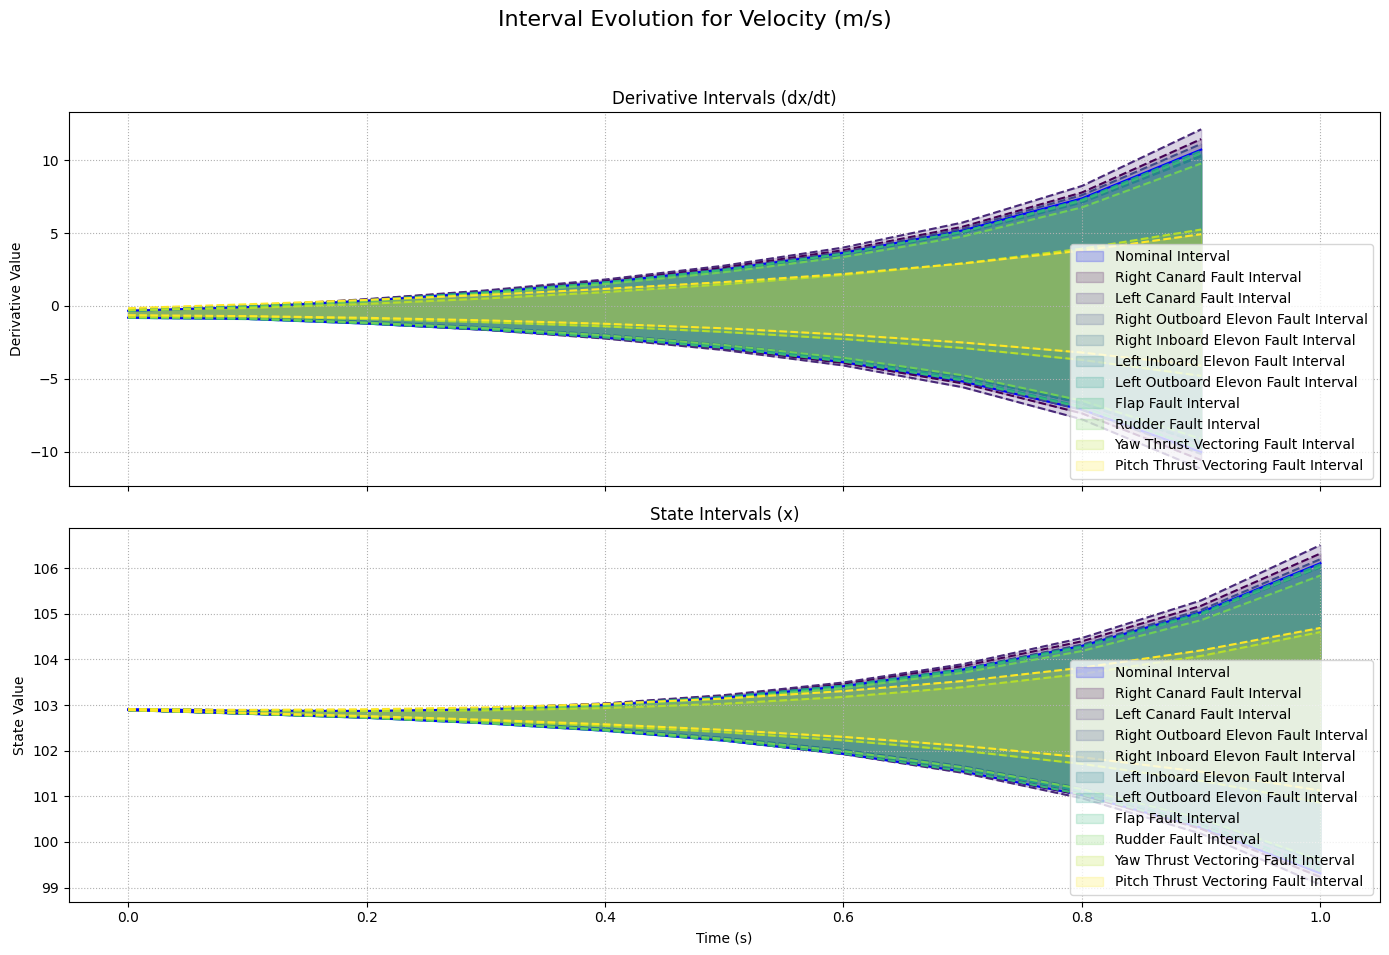

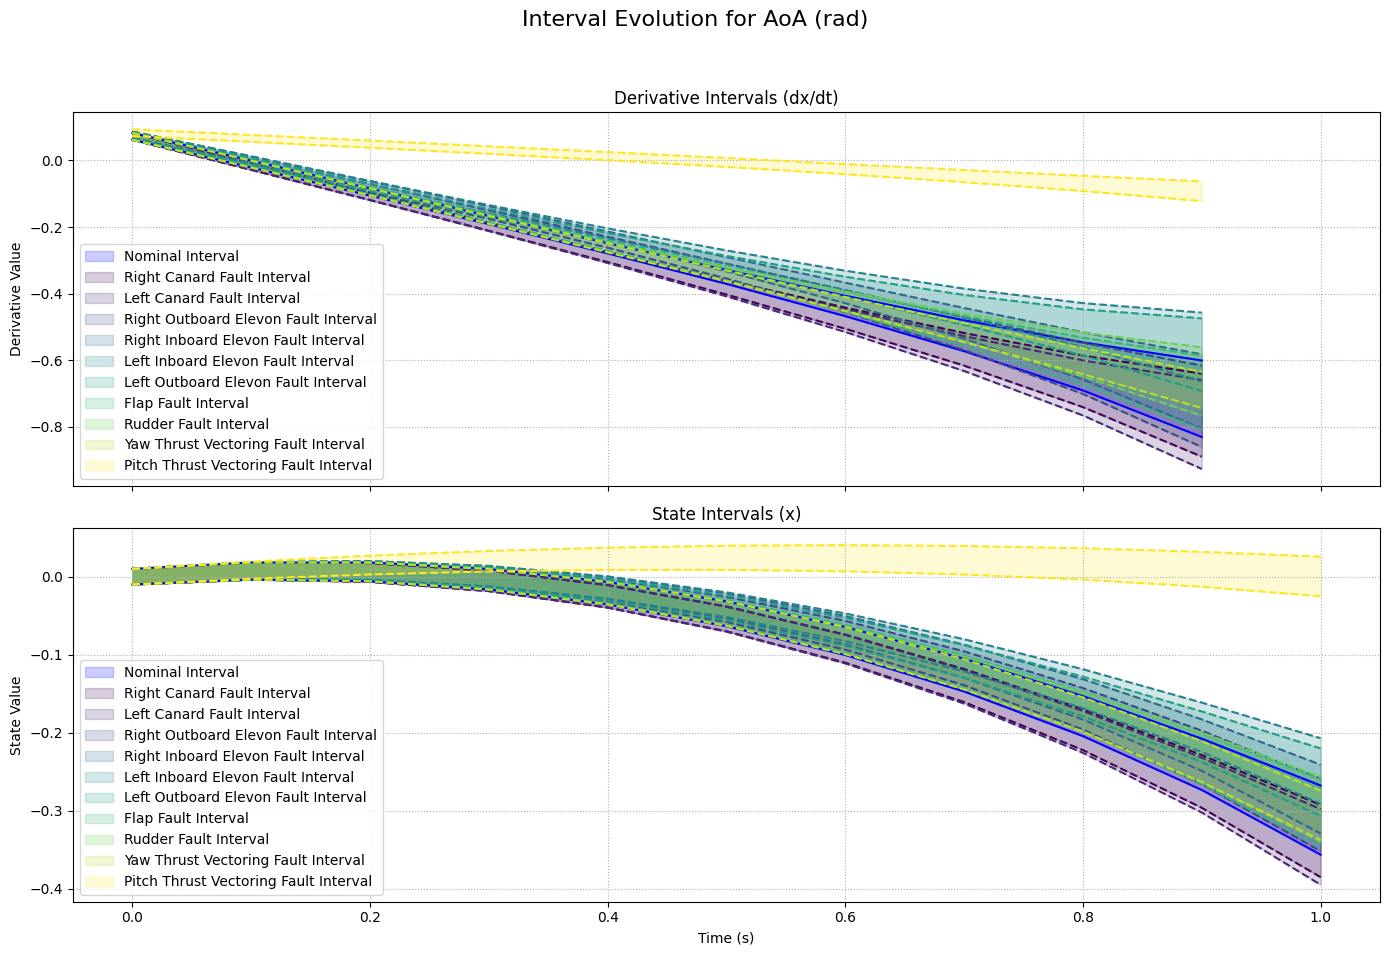

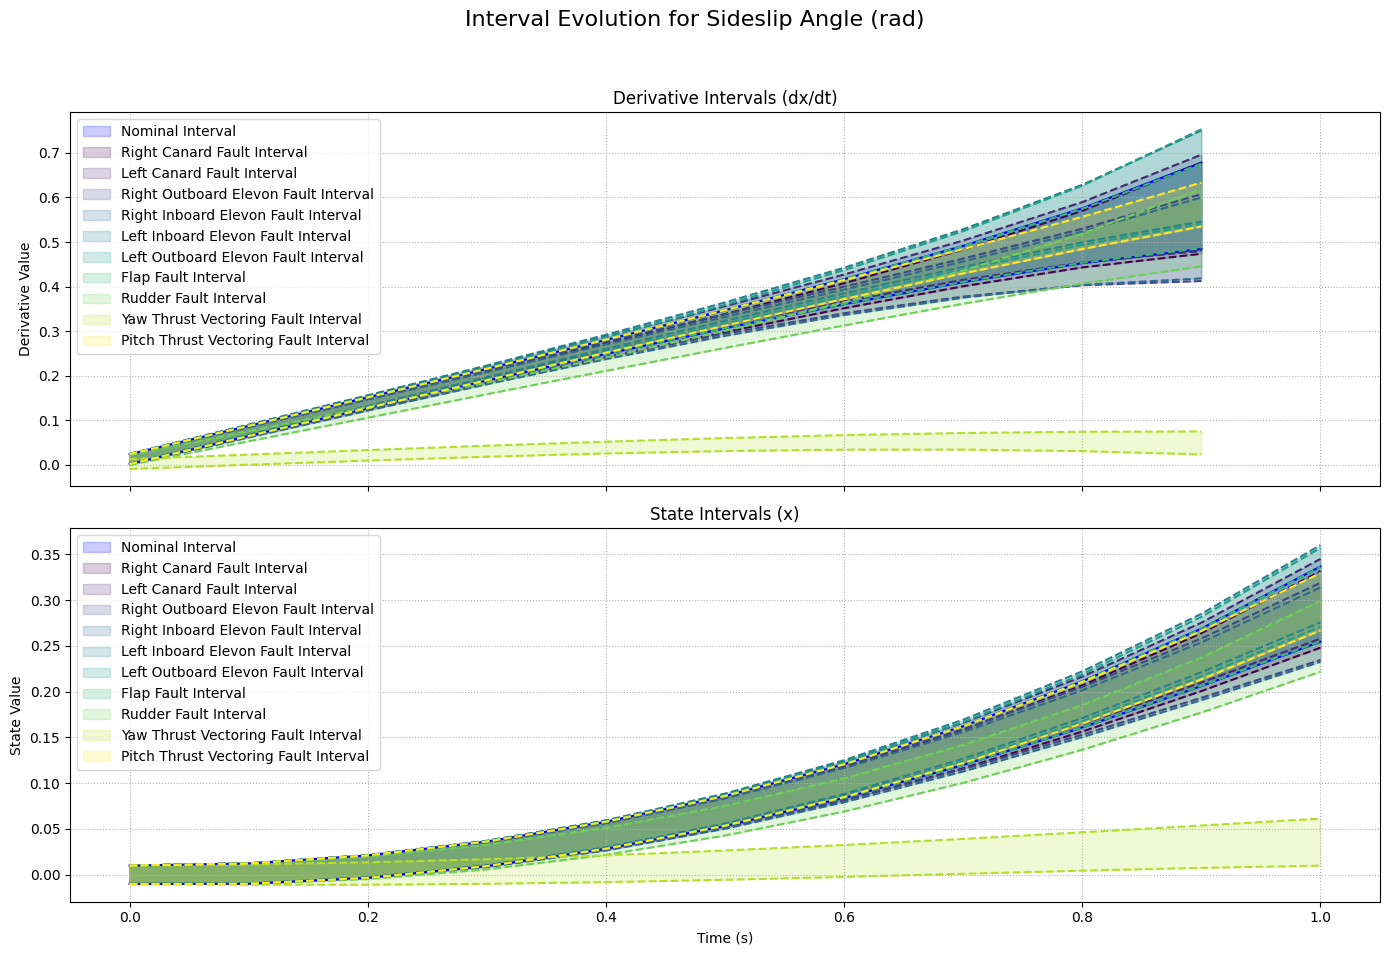

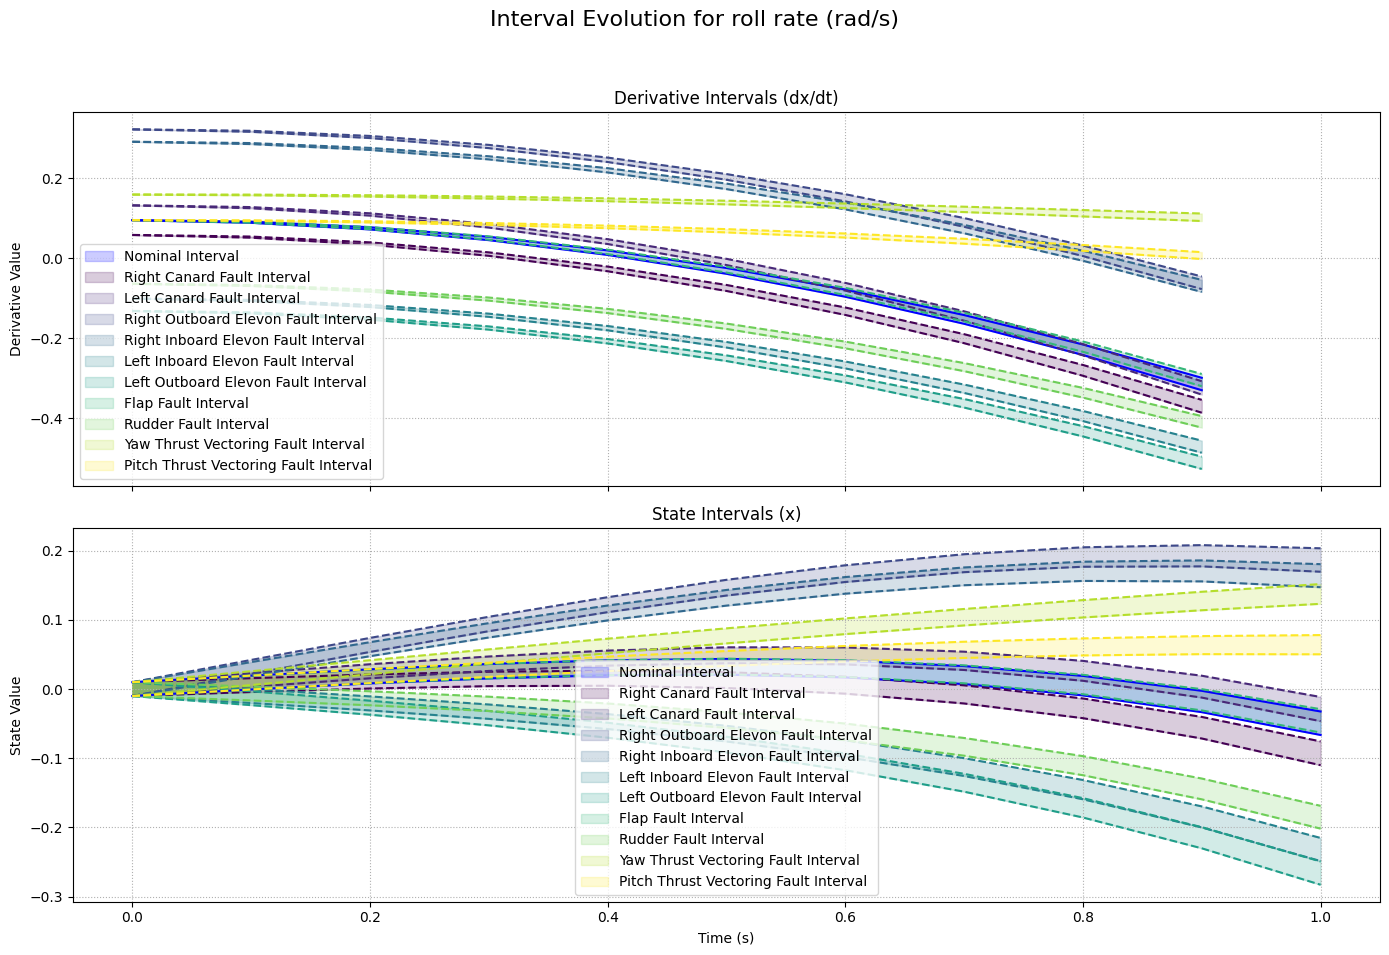

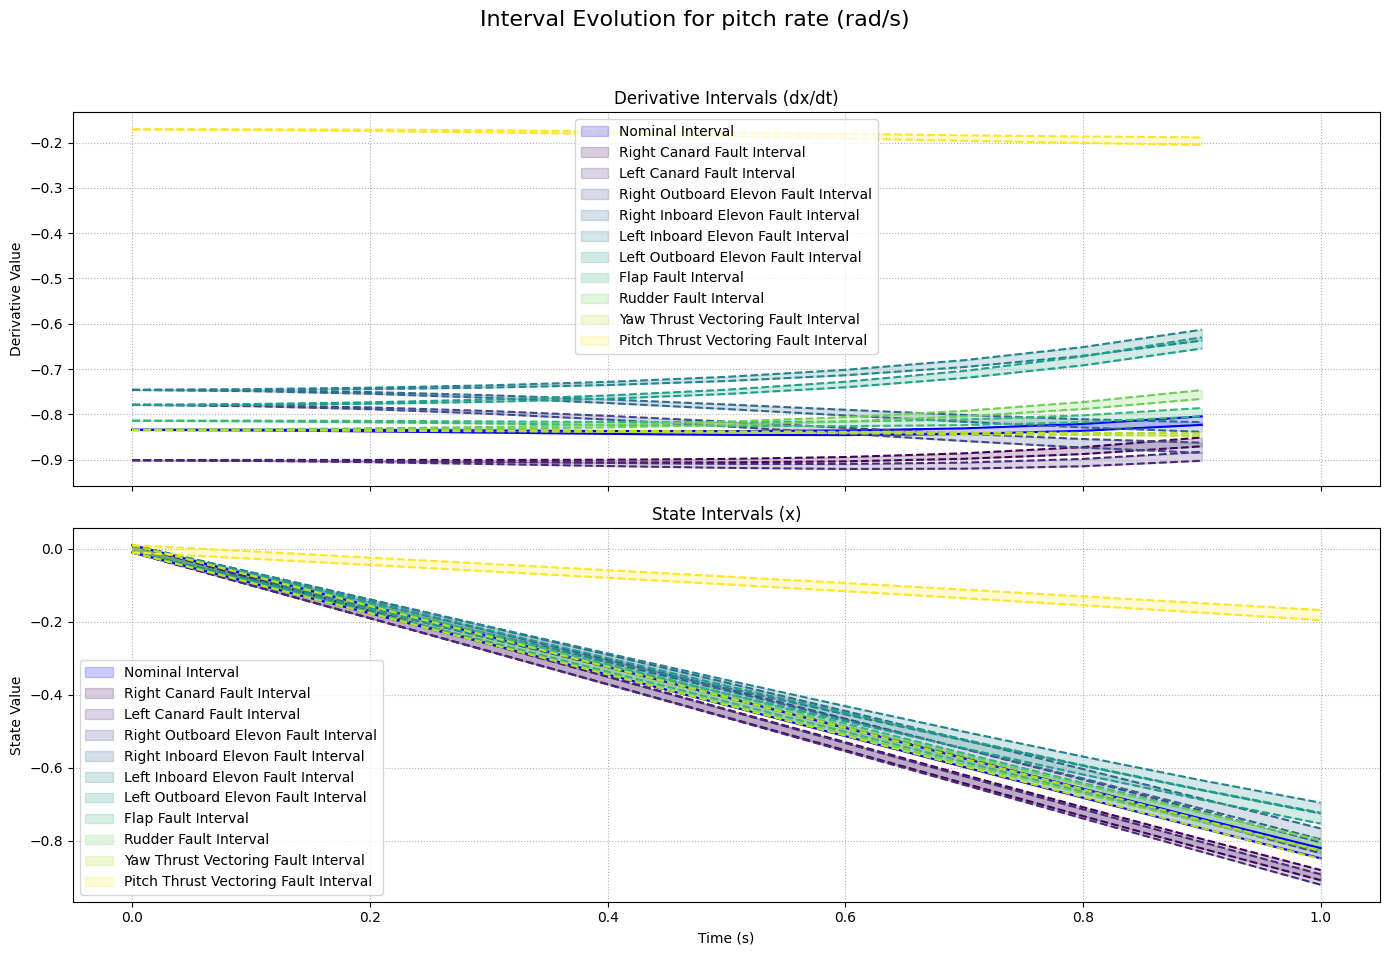

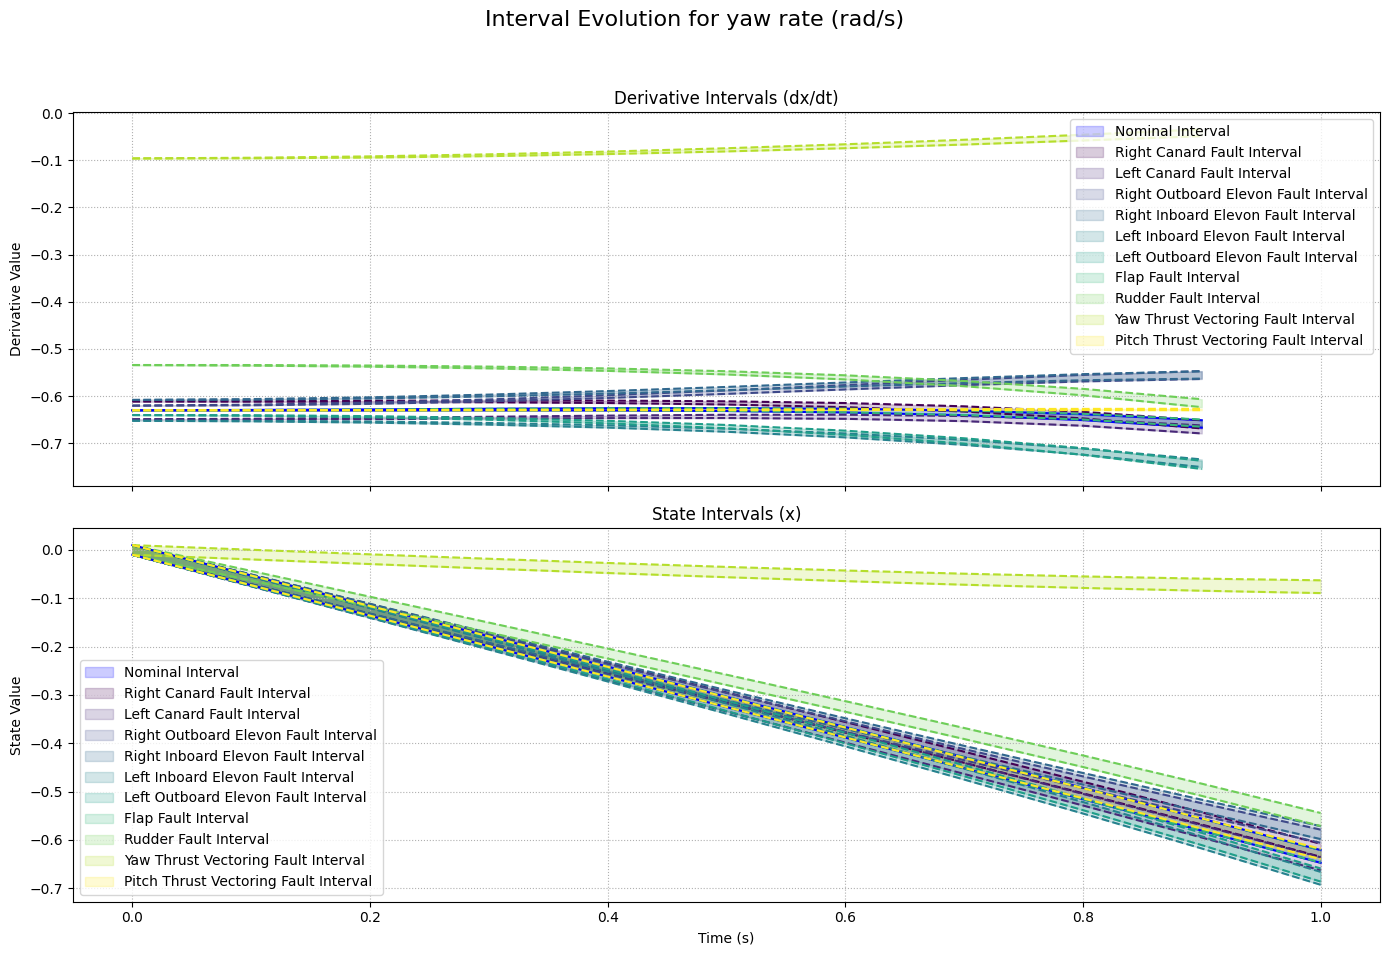

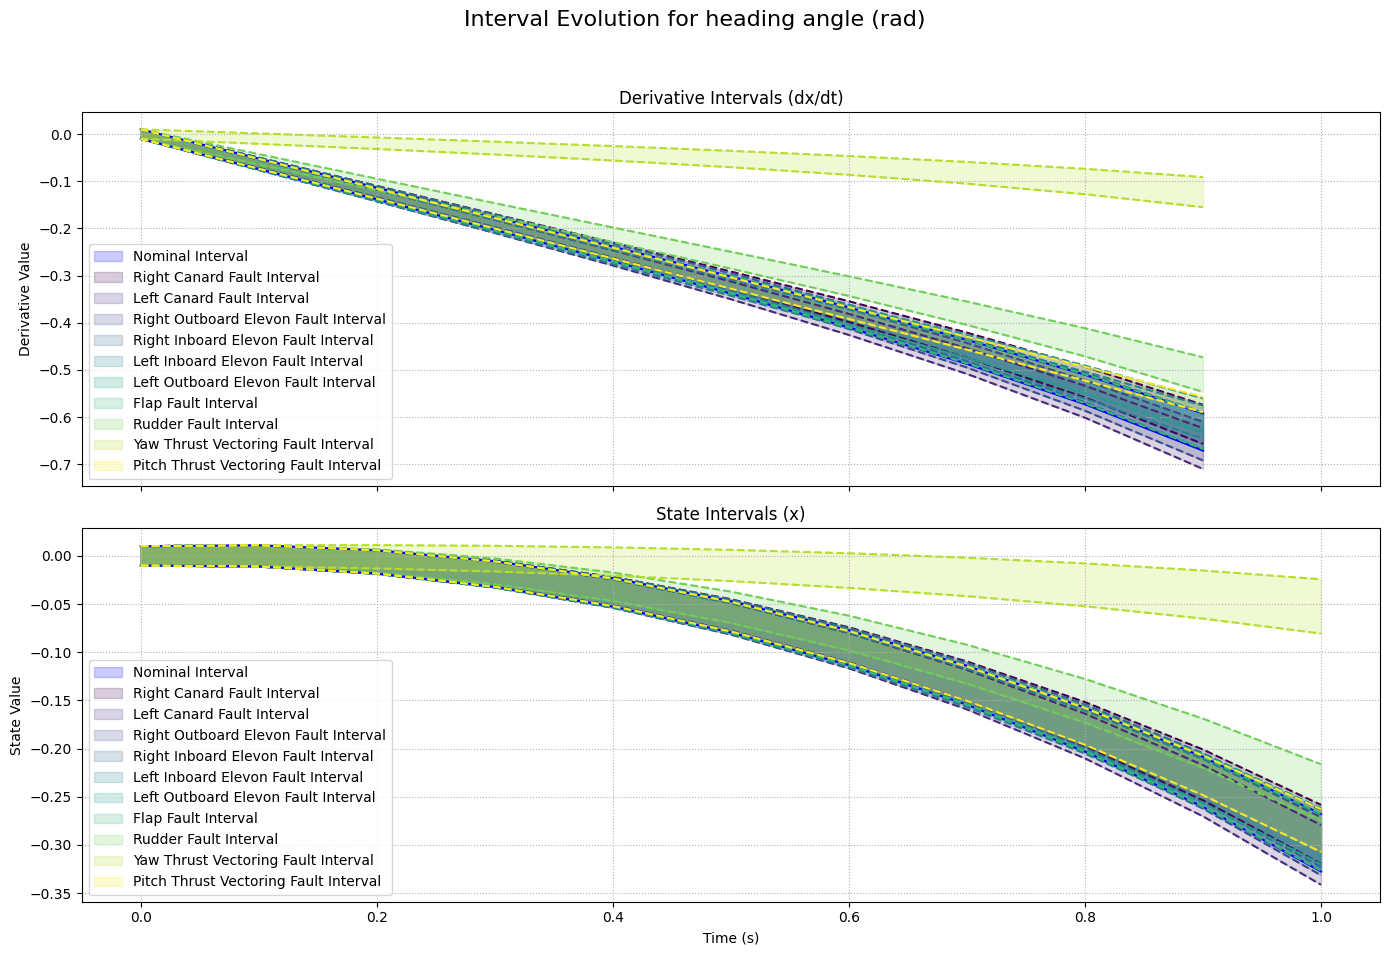

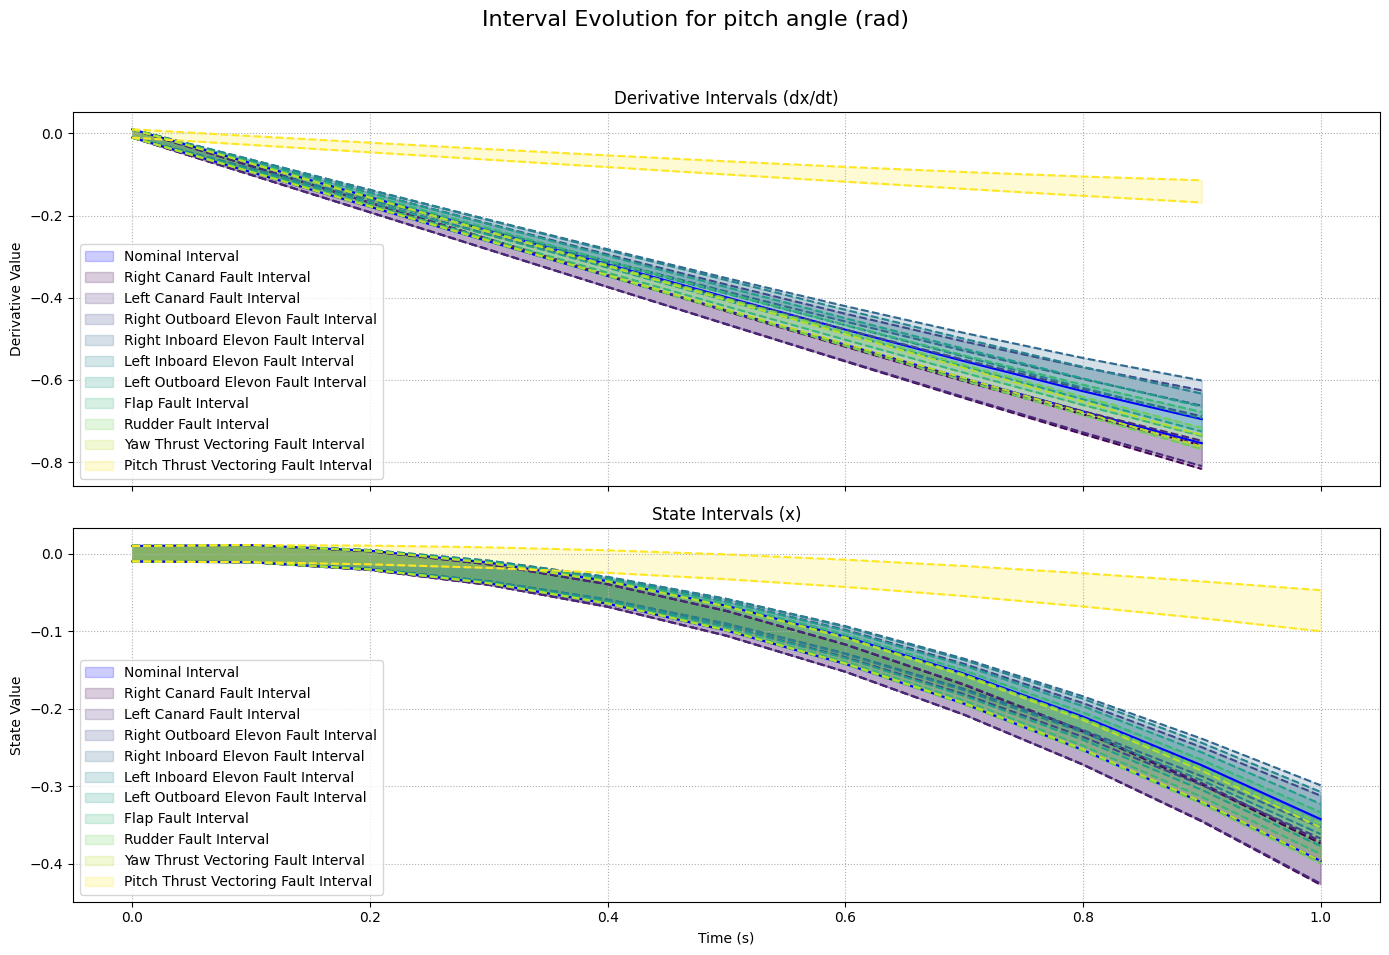

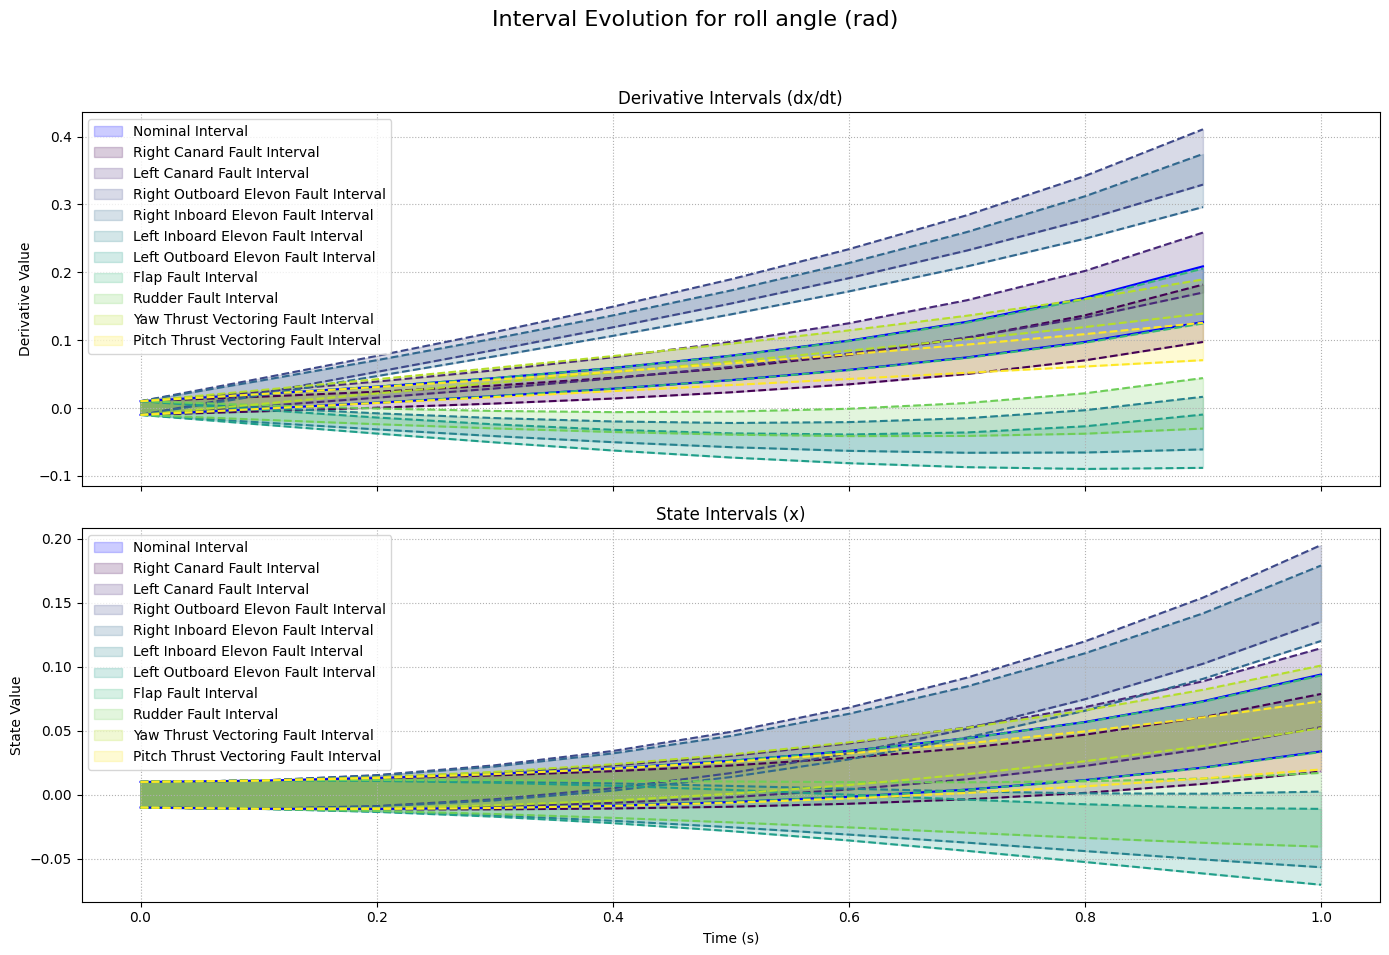

{'Nominal': {'states': [[ 1.0289e+02 -1.0000e-02 -1.0000e-02 -1.0000e-02 -1.0000e-02 -1.0000e-02
    -1.0000e-02 -1.0000e-02 -1.0000e-02] <= x <= [1.0291e+02 1.0000e-02 1.0000e-02 1.0000e-02 1.0000e-02 1.0000e-02
    1.0000e-02 1.0000e-02 1.0000e-02],
   [ 1.0280945e+02 -3.7819613e-03 -9.8080784e-03 -5.1006582e-04
    -9.3410499e-02 -7.3006421e-02 -1.1010050e-02 -1.1010000e-02
    -1.1010099e-02] <= x <= [ 1.0287716e+02  1.8248331e-02  1.2408078e-02  1.9510068e-02
    -7.3389515e-02 -5.2993596e-02  1.1010050e-02  1.1010000e-02
     1.1010099e-02],
   [ 1.02720634e+02 -5.91366366e-03 -3.33053526e-03  8.33674893e-03
    -1.76943690e-01 -1.36042297e-01 -1.84139851e-02 -2.04314291e-02
    -1.11405943e-02] <= x <= [ 1.0286982e+02  1.8174805e-02  2.1161297e-02  2.8630488e-02
    -1.5676937e-01 -1.1590955e-01  5.8138552e-03  3.7518716e-03
     1.3042617e-02],
   [ 1.0259990e+02 -1.6464770e-02  9.4009349e-03  1.5523155e-02
    -2.6068944e-01 -1.9907153e-01 -3.2251880e-02 -3.8277358e-02
    -1.

In [53]:
plot_intervals_generalized(
    u_ol=jnp.ones(10) * .1,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    fault_names=fault_names,
    fault_colors=None,
    dt=0.1,
    num_steps=10
)

In [54]:
import jaxopt
def find_optimal_open_loop_lbfgsb(
    x_interval: irx.Interval,
    u_initial: jnp.ndarray,
    bounds_u: Tuple[jnp.ndarray, jnp.ndarray], # <-- New: Box constraints for u
    p_nominal: irx.Interval,
    p_faults: List[irx.Interval],
    dt: float,
    num_sim_steps: int = 10,
    maxiter: int = 50,
    tol: float = 1e-4
):
    """
    Finds the optimal open-loop control input 'u_ol' using jaxopt.LBFGSB.

    Args:
        x_interval: The initial state interval.
        u_initial: The initial guess for the control input 'u_ol'.
        bounds_u: A tuple (lower_bounds, upper_bounds) for the control input 'u_ol'.
                  Bounds must have the same shape as u_initial.
        p_nominal: The parameter set for the nominal system.
        p_faults: A list of fault parameter Intervals.
        dt: The time step for propagation.
        num_sim_steps: The number of simulation steps for the loss function.
        maxiter: Maximum number of iterations for the L-BFGS-B algorithm.
        tol: Tolerance for the stopping condition.

    Returns:
        The optimized control input 'u_opt'.
    """
    # 1. Stack the list of Pytrees (fault parameters) into a single Pytree
    #    This is required for JAX transformations.
    if not p_faults:
        raise ValueError("The `p_faults` list cannot be empty.")
    p_faults_stacked = jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults)

    # 2. Define the objective function to be minimized.
    #    It must only take the variable we are optimizing (u_ol) as its first argument.
    #    We "freeze" the other parameters using a lambda function.
    def objective_fn(u_ol):
        return loss_ff_generalized_scan_vmap_jax(
            u_ol, x_interval, p_nominal, p_faults_stacked, dt, num_sim_steps
        )
    
    # 3. Instantiate the L-BFGS-B solver.
    #    We pass the objective function and can configure other parameters.
    #    `jit=True` tells jaxopt to JIT-compile the optimization loop.
    solver = jaxopt.LBFGSB(fun=objective_fn, tol=tol, maxiter=maxiter, jit=True)

    # 4. Run the optimization.
    #    The `run` method handles the entire optimization loop internally.
    #    It returns the solution Pytree and the final state of the optimizer.
    sol, state = solver.run(init_params=u_initial, bounds=bounds_u)

    # 5. Print results and return the optimal parameters.
    print("--- L-BFGS-B Optimization Finished ---")
    # print(f"Converged in {state.iter_num} iterations.")
    # print(f"Final loss value: {state.value:.6f}")
    
    u_opt = sol
    return u_opt

In [55]:
def calculate_optimal_tv_open_loop(x_interval, learning_rate, u_initial, p_nominal, p_fault1, p_fault2, dt, num_steps=100):
    num_gd_steps = 10
    # # Define the body of the gradient descent loop
    def gradient_step(i, u_current):
        grad = loss_3_grad(u_current, x_interval, p_nominal, p_fault1, p_fault2, dt, num_steps=num_steps)
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt

In [56]:
jit_find_optimal_open_loop_lbfgsb = jit(partial(
    find_optimal_open_loop_lbfgsb,
    p_nominal=p_nominal_ivl,
    p_faults=[p_flap_ivl, p_yaw_tv_ivl, p_rudder_ivl],
    dt=dt,
    num_sim_steps=num_steps
))

In [58]:
lower_bounds_u = jnp.ones(admire.ulen) * -.3
upper_bounds_u = jnp.ones(admire.ulen) * .3
bounds_u_tuple = (lower_bounds_u, upper_bounds_u)
# u_lbfgsb = jax.block_until_ready(
#     jit_find_optimal_open_loop_lbfgsb(
#         x_interval=x0_interval_admire,
#         u_initial=jnp.ones(admire.ulen) * .01,
#         bounds_u=bounds_u_tuple,
#     )
# )

### 3.4 Staged / Time-Varying Open Loop Input

In [11]:
def _calculate_pairwise_loss(all_ivls, scaling_divisor):
    """Helper to calculate the sum of pairwise overlaps for a set of intervals."""
    num_scenarios = jax.tree_util.tree_leaves(all_ivls)[0].shape[0]
    i_indices, j_indices = jnp.triu_indices(num_scenarios, k=1)
    
    ivls_i = jax.tree_util.tree_map(lambda leaf: leaf[i_indices], all_ivls)
    ivls_j = jax.tree_util.tree_map(lambda leaf: leaf[j_indices], all_ivls)
    scaling_divisors = jnp.broadcast_to(
        scaling_divisor, 
        (i_indices.shape[0], *scaling_divisor.shape)
    )
    
    pairwise_losses = jax.vmap(overlap_size_lax_scaled, in_axes=(0, 0, 0))(ivls_i, ivls_j, scaling_divisors)
    return jnp.sum(pairwise_losses)

def loss_ff_staged_product_jax(u_ols, x_interval, p_nominal, p_faults, dt, num_u_steps):
    """
    Calculates a staged distinguishability loss.

    This function simulates a nominal and multiple fault scenarios. It applies a
    sequence of `N` open-loop controls (`u_ols`), each for `num_u_steps`.
    
    After each control stage, it calculates the total pairwise overlap between all
    scenarios (nominal + faults). The final loss is the *product* of these `N`
    intermediate loss values. A lower final loss is better, indicating that
    the states remained distinguishable at each stage.

    Args:
        u_ols (PyTree): A PyTree of JAX arrays, where each leaf has a leading
            dimension `N`, representing the sequence of N control inputs.
        x_interval (PyTree): The initial state interval.
        p_nominal (PyTree): Parameters for the nominal system.
        p_faults (PyTree): A PyTree of JAX arrays, where each leaf has a leading
            dimension `F`, representing F different fault scenarios.
        dt (float): The simulation time step.
        num_u_steps (int): The number of simulation steps per control stage.

    Returns:
        float: The final scalar loss, which is the product of stage-wise losses.
    """

    # Calculate Scaling factor
    scaling_divisors = x_interval.upper - x_interval.lower
    
    # Add a small epsilon to prevent division by zero if an initial interval has zero width.
    # scaling_divisors = jnp.maximum(scaling_divisors, 1e-6)

    num_faults = jax.tree_util.tree_leaves(p_faults)[0].shape[0]
    num_scenarios = 1 + num_faults

    # 1. Combine nominal and fault parameters into a single Pytree
    # This makes it easy to vmap the simulation over all scenarios.
    p_nominal_expanded = jax.tree_util.tree_map(lambda p: jnp.expand_dims(p, axis=0), p_nominal)
    all_params = jax.tree_util.tree_map(
        lambda n, f: jnp.concatenate([n, f], axis=0),
        p_nominal_expanded, p_faults
    )

    # 2. Prepare the initial state for all scenarios
    # All scenarios start from the same initial interval.
    all_x_ivls_initial = jax.tree_util.tree_map(
        lambda leaf: jnp.repeat(jnp.expand_dims(leaf, axis=0), num_scenarios, axis=0),
        x_interval
    )

    # 3. Define the function for the main scan over control stages
    def stage_scan_fn(carry_all_x_ivls, u_stage):
        # `carry_all_x_ivls`: PyTree of state intervals for all scenarios at the start of the stage.
        # `u_stage`: The single control vector to be applied for this stage.

        # 3a. Define an inner scan to simulate one stage (num_u_steps) for a single scenario
        def _propagate_one_scenario_for_stage(x_ivl_start, p_scenario):
            def _inner_scan_fn(x_ivl_carry, _):
                # The control `u_stage` is constant for this inner scan.
                x_ivl_next = propagate_interval_euler_admire(x_ivl_carry, u_stage, p_scenario, dt)
                return x_ivl_next, None
            
            # Run the simulation for num_u_steps and return the final state
            x_ivl_final, _ = jax.lax.scan(_inner_scan_fn, x_ivl_start, None, length=num_u_steps)
            return x_ivl_final

        # 3b. Use vmap to run the stage simulation for all scenarios in parallel
        all_x_ivls_end_of_stage = jax.vmap(_propagate_one_scenario_for_stage)(carry_all_x_ivls, all_params)

        # 3c. Calculate the pairwise loss at the end of this stage
        loss_at_stage = _calculate_pairwise_loss(all_x_ivls_end_of_stage, scaling_divisors)
        
        # 3d. The new carry is the set of final states, and the output is the stage loss
        return all_x_ivls_end_of_stage, loss_at_stage

    # 4. Run the main scan over the `N` control stages
    # The initial carry is the initial state for all scenarios.
    # The `xs` are the `N` control inputs from `u_ols`.
    _, all_stage_losses = jax.lax.scan(
        stage_scan_fn, all_x_ivls_initial, u_ols
    )
    
    # 5. The final loss is the product of the losses from each stage
    return jnp.prod(all_stage_losses)

In [12]:
jax_grad_staged = jax.grad(loss_ff_staged_product_jax, argnums=0)

def calculate_optimal_staged(x_interval, learning_rate, u_initial, p_nominal, p_faults, dt, num_u_steps=5, num_gd_steps=10):
    # # Define the body of the gradient descent loop
    p_faults_stacked = jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults)
    def gradient_step(i, u_current):
        grad = jax_grad_staged(u_current, x_interval, p_nominal, p_faults_stacked, dt, num_u_steps)
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt

In [18]:
p_faults_list = [p_rc_ivl, p_lc_ivl, p_roe_ivl, p_rie_ivl, p_lie_ivl, p_loe_ivl, p_flap_ivl, p_rudder_ivl, p_yaw_tv_ivl, p_pitch_tv_ivl]
fault_names = [
    "Right Canard Fault", 
    "Left Canard Fault", 
    "Right Outboard Elevon Fault",
    "Right Inboard Elevon Fault",
    "Left Inboard Elevon Fault",
    "Left Outboard Elevon Fault",
    "Flap Fault",
    "Rudder Fault",
    "Yaw Thrust Vectoring Fault", 
    "Pitch Thrust Vectoring Fault"
    ]

In [19]:
jit_find_optimal_staged = jit(partial(
    calculate_optimal_staged,
    num_u_steps=10,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    dt=0.05,
    num_gd_steps=num_steps
))

In [17]:
p_faults_list = [#p_rc_ivl, p_lc_ivl, p_roe_ivl, p_rie_ivl, p_lie_ivl, p_loe_ivl, 
                 p_flap_ivl]#, p_rudder_ivl, p_yaw_tv_ivl, p_pitch_tv_ivl]
fault_names = [
    # "Right Canard Fault", 
    # "Left Canard Fault", 
    # "Right Outboard Elevon Fault",
    # "Right Inboard Elevon Fault",
    # "Left Inboard Elevon Fault",
    # "Left Outboard Elevon Fault",
    "Flaps Fault",
    # "Rudder Fault",
    # "Yaw Thrust Vectoring Fault", 
    # "Pitch Thrust Vectoring Fault"
    ]
smart_u_2stage_initial_guess = jnp.array([[0., 0., 0., 0., 0., 0., 0., .1, 0., 0.],
                             [.1, .1, .1, .1, .1, .1, .1, .1, .1, .1]])

In [20]:
u_staged_opt = jax.block_until_ready(
    jit_find_optimal_staged(
        x0_interval_admire,
        1e-5,
        smart_u_2stage_initial_guess
    )
)

In [27]:
u_staged_opt = jit_find_optimal_staged(
    x0_interval_admire,
    5e-9,
    smart_u_2stage_initial_guess
)

In [30]:
u_staged_opt = jit_find_optimal_staged(
    x0_interval_admire,
    1e-10,
    smart_u_2stage_initial_guess
)

In [31]:
print(u_staged_opt)

[[-3.98623997e-05  1.74386404e-03  2.34413967e-02 -7.57532800e-03
  -1.07876705e-02  2.07514595e-02 -4.28387476e-03  1.15011908e-01
  -1.59837957e-02 -8.15446395e-03]
 [ 1.00122243e-01  1.00998193e-01  1.20139726e-01  9.35535952e-02
   8.86978656e-02  1.21432282e-01  9.79007334e-02  1.13496006e-01
   9.24252942e-02  9.44891050e-02]]


In [32]:
print(loss_ff_staged_product_jax(u_staged_opt, x0_interval_admire, p_nominal_ivl, 
                                 jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults_list), 0.1, 10))

0.0


In [33]:
print(loss_ff_staged_product_jax(smart_u_2stage_initial_guess, x0_interval_admire, p_nominal_ivl, 
                                 jax.tree_util.tree_map(lambda *leaves: jnp.stack(leaves), *p_faults_list), 0.1, 10))

397341440.0


In [34]:
smart_u_2stage_initial_guess = jnp.array([[0., 0., 0., 0., 0., 0., 0., jnp.pi/6, 0., 0.],
                             [.1, .1, .1, .1, .1, .1, .1, .1, .1, .1]])

In [38]:
final_ivls = plot_staged_intervals_generalized(
    u_ols=u_staged_opt,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    fault_names=fault_names,
    num_u_steps=20,
    dt = .025,
    save_to_pdf=True,
    plot_derivatives=False,
)

/tmp/ipykernel_715411/297681154.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(p_faults))


Starting simulation for 2 stages (40 total steps)...
Plots will be saved to: staged_interval_plots_20250817192347.pdf
PDF generation complete.


In [ ]:
with open("final_intervals.pkl", "wb") as f:
    pickle.dump(final_ivls, f)

In [11]:
with open('final_intervals.pkl', 'rb') as f:
    loaded_states = pickle.load(f)


### Debug function: Plot final intervals

In [66]:
def plot_final_intervals_generalized(
    u_ols: jnp.ndarray,
    x_interval: irx.Interval,
    p_nominal: irx.Interval,
    p_faults: List[irx.Interval],
    fault_names: List[str],
    fault_colors: Optional[List[str]] = None,
    dt: float = 0.1,
    num_u_steps: int = 10,
    save_to_pdf: bool = False
) -> Dict[str, Any]:
    """
    Simulates staged control and plots only the final state intervals for comparison.

    Args:
        u_ols: A sequence of open-loop controls. Shape (num_stages, u_dim).
        x_interval: Initial interval for the state vector.
        p_nominal: Nominal parameter set as an Interval.
        p_faults: A list of parameter Intervals for each fault scenario.
        fault_names: A list of names for each fault scenario.
        fault_colors: (Optional) A list of color strings for faults.
        dt: Time step for Euler integration.
        num_u_steps: The number of simulation steps to apply each control for.
        save_to_pdf: If True, saves all plots to 'final_interval_plots.pdf'.

    Returns:
        A dictionary containing the full history of states and derivatives.
    """
    if plt is None:
        print("Skipping plotting as Matplotlib is not available.")
        return {}

    # --- 1. Simulation (Identical to the previous function) ---
    assert len(p_faults) == len(fault_names), "Length of p_faults and fault_names must match."
    num_stages, total_sim_steps = u_ols.shape[0], u_ols.shape[0] * num_u_steps
    scenarios, p_params = ["Nominal"] + fault_names, [p_nominal] + p_faults
    
    if fault_colors is None:
        cmap = plt.cm.get_cmap('viridis', len(p_faults))
        generated_colors = [cmap(i) for i in range(len(p_faults))]
    else:
        generated_colors = fault_colors
    color_map = {"Nominal": "blue", **{name: color for name, color in zip(fault_names, generated_colors)}}
        
    history = {name: {"states": [x_interval]} for name in scenarios}
    current_states = [copy.deepcopy(x_interval) for _ in scenarios]

    print(f"Starting simulation for {num_stages} stages ({total_sim_steps} total steps)...")
    for stage_idx in range(num_stages):
        u_current_stage = u_ols[stage_idx]
        for _ in range(num_u_steps):
            for j, name in enumerate(scenarios):
                p_current, x_current = p_params[j], current_states[j]
                derivatives_ut = admire_embsys.f(0, irx.i2ut(x_current), u_current_stage, p_current)
                derivative_ivl = irx.ut2i(derivatives_ut)
                new_state = (derivative_ivl * dt) + x_current
                history[name]["states"].append(new_state)
                current_states[j] = new_state
    
    # --- 2. Extract Final Intervals ---
    final_intervals = {name: history[name]["states"][-1] for name in scenarios}
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]

    # --- 3. Plotting Setup with Fixed PDF Name ---
    pdf_pages = None
    if save_to_pdf:
        filename = "final_interval_plots.pdf"
        pdf_pages = PdfPages(filename)
        print(f"Plots will be saved to: {filename}")
    else:
        print("Generating final interval plots to display...")

    # --- 4. Main Plotting Loop for Final Intervals ---
    num_dims = x_interval.lower.shape[0]
    y_pos = jnp.arange(len(scenarios))

    for dim in range(num_dims):
        fig, ax = plt.subplots(figsize=(10, 2 + len(scenarios) * 0.5))
        
        # Prepare data for error bars
        centers = []
        half_widths = []
        for name in scenarios:
            final_ivl = final_intervals[name]
            lower_bound = final_ivl.lower[dim]
            upper_bound = final_ivl.upper[dim]
            centers.append((lower_bound + upper_bound) / 2)
            half_widths.append((upper_bound - lower_bound) / 2)
        
        # Create a horizontal error bar for each scenario
        for i, name in enumerate(scenarios):
            ax.errorbar(
                x=centers[i],
                y=y_pos[i],
                xerr=half_widths[i],
                fmt='o',  # 'o' places a marker at the interval center
                color=color_map[name],
                capsize=5, # Makes the end caps visible
                label=name
            )

        # Formatting the plot for clarity
        ax.set_yticks(y_pos)
        ax.set_yticklabels(scenarios)
        ax.invert_yaxis()  # Puts "Nominal" at the top
        
        ax.set_title(f'Final State Intervals for {dim_names[dim]}')
        ax.set_xlabel('State Value')
        ax.set_ylabel('Scenario')
        ax.grid(True, linestyle=':', axis='x')
        
        plt.tight_layout()
        
        # --- 5. Save to PDF or Display ---
        if save_to_pdf:
            pdf_pages.savefig(fig)
            plt.close(fig)
        else:
            plt.show()

    # --- 6. Finalize PDF ---
    if save_to_pdf:
        pdf_pages.close()
        print("PDF generation complete.")

    # Return the full history, as it might still be useful
    return history

In [68]:
plot_final_intervals_generalized(
    u_ols=u_staged_opt,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    fault_names=fault_names,
    num_u_steps=5,
    dt = .1,
    save_to_pdf=True,
)

/tmp/ipykernel_221123/374833331.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(p_faults))


Starting simulation for 2 stages (10 total steps)...
Plots will be saved to: final_interval_plots.pdf
PDF generation complete.


{'Nominal': {'states': [[ 1.0289e+02 -1.0000e-02 -1.0000e-02 -1.0000e-02 -1.0000e-02 -1.0000e-02
    -1.0000e-02 -1.0000e-02 -1.0000e-02] <= x <= [1.0291e+02 1.0000e-02 1.0000e-02 1.0000e-02 1.0000e-02 1.0000e-02
    1.0000e-02 1.0000e-02 1.0000e-02],
   [ 1.0287133e+02 -1.4206013e-03 -1.1187332e-02 -9.9591706e-03
    -1.6357044e-02 -6.1438619e-03 -1.1010050e-02 -1.1010000e-02
    -1.1010099e-02] <= x <= [1.0293904e+02 2.0609692e-02 1.1028824e-02 1.0060961e-02 3.6639445e-03
    1.3868964e-02 1.1010050e-02 1.1010000e-02 1.1010099e-02],
   [ 1.02860176e+02  6.51681051e-03 -1.27826128e-02 -9.91711486e-03
    -2.27178112e-02 -2.29145563e-03 -1.16424831e-02 -1.26609737e-02
    -1.20214839e-02] <= x <= [ 1.0298283e+02  3.0593360e-02  1.1692252e-02  1.0132795e-02
    -2.6679202e-03  1.7742371e-02  1.2415040e-02  1.1391664e-02
     1.2031510e-02],
   [ 1.0285458e+02  1.3807783e-02 -1.4786620e-02 -9.8701147e-03
    -2.9082181e-02  1.5574864e-03 -1.1898981e-02 -1.4954101e-02
    -1.3036004e-02] 

In [ ]:
# Assume irx and other custom modules are defined elsewhere
# from your_project import irx

def plot_3d_final_intervals(
    history: Dict[str, Any],
    dim_names: List[str],
    color_map: Optional[Dict[str, str]] = None,
    save_to_pdf: bool = False,
    pdf_pages: Optional[PdfPages] = None
) -> None:
    """
    Generates a readable 3D plot of final state intervals for dimensions 4, 5, and 6,
    with larger fonts and auto-scaled tight axis limits.

    Args:
        history: The output dictionary from the simulation function.
        dim_names: A list of names for each state dimension for axis labeling.
        color_map: (Optional) A dictionary mapping scenario names to colors.
        save_to_pdf: If True, saves the plot to a PDF file.
        pdf_pages: (Optional) An existing PdfPages object to add the plot to.
    """
    # --- 1. Setup and Color Map Generation (Unchanged) ---
    if color_map is None:
        scenarios = list(history.keys())
        fault_names = [name for name in scenarios if name != "Nominal"]
        cmap = plt.cm.get_cmap('viridis', len(fault_names))
        generated_colors = [cmap(i) for i in range(len(fault_names))]
        color_map = {name: color for name, color in zip(fault_names, generated_colors)}
        if "Nominal" in scenarios: color_map["Nominal"] = "blue"

    print("Generating 3D plot for dimensions 4, 5, and 6 (indices 3, 4, 5)...")
    scenarios = list(history.keys())
    final_intervals = {name: history[name]["states"][-1] for name in scenarios}

    # ##################################################################
    # ### SECTION 2: NEW - CALCULATE TIGHT AXIS LIMITS DYNAMICALLY   ###
    # ##################################################################
    # Initialize min/max trackers with opposite infinities
    min_x, max_x = float('inf'), float('-inf')
    min_y, max_y = float('inf'), float('-inf')
    min_z, max_z = float('inf'), float('-inf')

    # Find the global min and max across all intervals for the 3 dimensions
    for ivl in final_intervals.values():
        min_x = min(min_x, ivl.lower[3])
        max_x = max(max_x, ivl.upper[3])
        min_y = min(min_y, ivl.lower[4])
        max_y = max(max_y, ivl.upper[4])
        min_z = min(min_z, ivl.lower[5])
        max_z = max(max_z, ivl.upper[5])

    # Helper function to add a small padding to the limits
    def get_padded_limits(min_val, max_val, padding_factor=0.05):
        range_val = max_val - min_val
        # Handle the case where the range is zero to avoid invisible plots
        if range_val == 0: range_val = abs(max_val) * 0.1 or 0.1
        padding = range_val * padding_factor
        return [min_val - padding, max_val + padding]

    x_lims = get_padded_limits(min_x, max_x)
    y_lims = get_padded_limits(min_y, max_y)
    z_lims = get_padded_limits(min_z, max_z)
    
    # --- 3. Plotting Setup and Loop (Unchanged) ---
    fig_3d = plt.figure(figsize=(12, 10))
    ax_3d = fig_3d.add_subplot(111, projection='3d')

    def create_cuboid_faces(x_range, y_range, z_range):
        x0,x1=x_range; y0,y1=y_range; z0,z1=z_range
        v=[(x0,y0,z0),(x1,y0,z0),(x1,y1,z0),(x0,y1,z0),(x0,y0,z1),(x1,y0,z1),(x1,y1,z1),(x0,y1,z1)]
        f=[[v[0],v[1],v[2],v[3]],[v[4],v[5],v[6],v[7]],[v[0],v[1],v[5],v[4]],
           [v[2],v[3],v[7],v[6]],[v[0],v[3],v[7],v[4]],[v[1],v[2],v[6],v[5]]]
        return f
    
    for name in scenarios:
        final_ivl = final_intervals[name]
        collection = Poly3DCollection(
            create_cuboid_faces(
                (final_ivl.lower[3], final_ivl.upper[3]),
                (final_ivl.lower[4], final_ivl.upper[4]),
                (final_ivl.lower[5], final_ivl.upper[5])
            ),
            facecolors=color_map[name], linewidths=1, edgecolors='k', alpha=0.20
        )
        ax_3d.add_collection3d(collection)
        
    # ##############################################################
    # ### SECTION 4: MODIFIED - APPLY LIMITS AND LARGER FONTS    ###
    # ##############################################################
    # Define font sizes for easy modification
    TITLE_FONTSIZE = 32
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 16

    # Apply the calculated tight axis limits
    ax_3d.set_xlim(min_x, max_x)
    ax_3d.set_ylim(min_y, max_y)
    ax_3d.set_zlim(min_z, max_z)

    # Apply font sizes to labels and title
    ax_3d.set_xlabel(dim_names[3], fontsize=LABEL_FONTSIZE, labelpad=15)
    ax_3d.set_ylabel(dim_names[4], fontsize=LABEL_FONTSIZE, labelpad=15)
    ax_3d.set_zlabel(dim_names[5], fontsize=LABEL_FONTSIZE, labelpad=15)
    # ax_3d.set_title("3D Final State Intervals for Rotational Rates", fontsize=TITLE_FONTSIZE, pad=20)

    # Apply font size to tick labels
    ax_3d.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax_3d.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    ax_3d.tick_params(axis='z', labelsize=TICK_FONTSIZE)
    
    # Legend and grid
    legend_patches = [Rectangle((0, 0), 1, 1, fc=color_map[name], alpha=0.5, label=name) for name in scenarios]
    ax_3d.legend(handles=legend_patches, fontsize=TICK_FONTSIZE, loc='upper right', bbox_to_anchor=(0.95, 1.0))
    ax_3d.grid(True)
    plt.tight_layout()

    # --- 5. Save/Display Logic (Unchanged) ---
    if save_to_pdf:
        create_own_pdf = pdf_pages is None
        if create_own_pdf:
            default_filename = "3d_final_intervals_plot.pdf"
            print(f"No PdfPages object provided. Saving to new file: {default_filename}")
            pdf_pages = PdfPages(default_filename)
        pdf_pages.savefig(fig_3d, bbox_inches='tight', pad_inches=0)
        if create_own_pdf:
            pdf_pages.close()
            print("PDF generation complete.")
    else:
        plt.show()
    plt.close(fig_3d)

In [15]:
def plot_3d_interval_history(
    history: Dict[str, Any],
    dim_names: List[str],
    color_map: Optional[Dict[str, str]] = None,
    save_to_pdf: bool = False,
    pdf_pages: Optional[PdfPages] = None
) -> None:
    """
    Generates a 3D plot of the state interval history for dimensions 4, 5, and 6.
    The history is rendered as a faint, transparent tube, and the final state
    interval is shown as a more solid, concrete box.

    Args:
        history: The output dictionary from the simulation function, containing
                 a list of state intervals for each scenario.
        dim_names: A list of names for each state dimension for axis labeling.
        color_map: (Optional) A dictionary mapping scenario names to colors.
        save_to_pdf: If True, saves the plot to a PDF file.
        pdf_pages: (Optional) An existing PdfPages object to add the plot to.
    """
    # --- 1. Setup and Color Map Generation (Unchanged) ---
    if color_map is None:
        scenarios = list(history.keys())
        fault_names = [name for name in scenarios if name != "Nominal"]
        cmap = plt.cm.get_cmap('viridis', len(fault_names))
        generated_colors = [cmap(i) for i in range(len(fault_names))]
        color_map = {name: color for name, color in zip(fault_names, generated_colors)}
        if "Nominal" in scenarios: color_map["Nominal"] = "blue"

    print("Generating 3D history plot for dimensions 4, 5, and 6 (indices 3, 4, 5)...")
    scenarios = list(history.keys())

    ######################################################################
    ### SECTION 2: MODIFIED - CALCULATE LIMITS OVER ENTIRE HISTORY     ###
    ######################################################################
    min_x, max_x = float('inf'), float('-inf')
    min_y, max_y = float('inf'), float('-inf')
    min_z, max_z = float('inf'), float('-inf')

    # Find the global min and max across ALL intervals in the history
    for name in scenarios:
        for ivl in history[name]["states"]:
            min_x = min(min_x, ivl.lower[3])
            max_x = max(max_x, ivl.upper[3])
            min_y = min(min_y, ivl.lower[4])
            max_y = max(max_y, ivl.upper[4])
            min_z = min(min_z, ivl.lower[5])
            max_z = max(max_z, ivl.upper[5])

    # Helper function to add a small padding to the limits (unchanged)
    def get_padded_limits(min_val, max_val, padding_factor=0.05):
        range_val = max_val - min_val
        if range_val == 0: range_val = abs(max_val) * 0.1 or 0.1
        padding = range_val * padding_factor
        return [min_val - padding, max_val + padding]

    x_lims = get_padded_limits(min_x, max_x)
    y_lims = get_padded_limits(min_y, max_y)
    z_lims = get_padded_limits(min_z, max_z)
    
    # --- 3. Plotting Setup (Unchanged) ---
    fig_3d = plt.figure(figsize=(12, 10))
    ax_3d = fig_3d.add_subplot(111, projection='3d')

    def create_cuboid_faces(x_range, y_range, z_range):
        x0,x1=x_range; y0,y1=y_range; z0,z1=z_range
        v=[(x0,y0,z0),(x1,y0,z0),(x1,y1,z0),(x0,y1,z0),(x0,y0,z1),(x1,y0,z1),(x1,y1,z1),(x0,y1,z1)]
        f=[[v[0],v[1],v[2],v[3]],[v[4],v[5],v[6],v[7]],[v[0],v[1],v[5],v[4]],
           [v[2],v[3],v[7],v[6]],[v[0],v[3],v[7],v[4]],[v[1],v[2],v[6],v[5]]]
        return f

    ######################################################################
    ### SECTION 4: MODIFIED - PLOT HISTORY TUBES AND FINAL BOXES       ###
    ######################################################################
    for name in scenarios:
        all_states = history[name]["states"]
        if not all_states:
            continue  # Skip if a scenario has no history

        # --- Part A: Plot the history as a faint tube ---
        # We collect all faces of the historical boxes and plot them in one go for efficiency.
        history_faces = []
        for ivl in all_states[:-1]: # Iterate over all but the last interval
            faces = create_cuboid_faces(
                (ivl.lower[3], ivl.upper[3]),
                (ivl.lower[4], ivl.upper[4]),
                (ivl.lower[5], ivl.upper[5])
            )
            history_faces.extend(faces)
        
        # Create a single collection for the entire history tube
        if history_faces:
            tube_collection = Poly3DCollection(
                history_faces,
                facecolors=color_map[name],
                linewidths=0, # No edges for a smoother look
                alpha=0.05     # Very low alpha to make it faint
            )
            ax_3d.add_collection3d(tube_collection)

        # --- Part B: Plot the final interval as a solid box ---
        final_ivl = all_states[-1]
        final_faces = create_cuboid_faces(
            (final_ivl.lower[3], final_ivl.upper[3]),
            (final_ivl.lower[4], final_ivl.upper[4]),
            (final_ivl.lower[5], final_ivl.upper[5])
        )
        final_box_collection = Poly3DCollection(
            final_faces,
            facecolors=color_map[name],
            linewidths=1,    # Solid edges
            edgecolors='k',
            alpha=0.30       # Higher alpha to make it stand out
        )
        ax_3d.add_collection3d(final_box_collection)
        
    # --- 5. Formatting, Limits, and Labels (Largely Unchanged) ---
    TITLE_FONTSIZE = 32
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 16

    ax_3d.set_xlim(x_lims)
    ax_3d.set_ylim(y_lims)
    ax_3d.set_zlim(z_lims)

    ax_3d.set_xlabel(dim_names[3], fontsize=LABEL_FONTSIZE, labelpad=15)
    ax_3d.set_ylabel(dim_names[4], fontsize=LABEL_FONTSIZE, labelpad=15)
    ax_3d.set_zlabel(dim_names[5], fontsize=LABEL_FONTSIZE, labelpad=15)
    
    ax_3d.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax_3d.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    ax_3d.tick_params(axis='z', labelsize=TICK_FONTSIZE)
    
    legend_patches = [Rectangle((0, 0), 1, 1, fc=color_map[name], alpha=0.6, label=name) for name in scenarios]
    ax_3d.legend(handles=legend_patches, fontsize=TICK_FONTSIZE, loc='upper right', bbox_to_anchor=(0.95, 1.0))
    ax_3d.grid(True)
    plt.tight_layout()

    # --- 6. Save/Display Logic (Unchanged) ---
    if save_to_pdf:
        create_own_pdf = pdf_pages is None
        if create_own_pdf:
            default_filename = "3d_interval_history_plot.pdf"
            print(f"No PdfPages object provided. Saving to new file: {default_filename}")
            pdf_pages = PdfPages(default_filename)
        pdf_pages.savefig(fig_3d, bbox_inches='tight', pad_inches=0)
        if create_own_pdf:
            pdf_pages.close()
            print("PDF generation complete.")
    else:
        plt.show()
    plt.close(fig_3d)

In [13]:
dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]

In [ ]:
plot_3d_final_intervals(
    history=final_ivls,
    dim_names=dim_names,
    save_to_pdf=True,
    color_map=None,
    pdf_pages=None,
)

Generating 3D plot for dimensions 4, 5, and 6 (indices 3, 4, 5)...
No PdfPages object provided. Saving to new file: 3d_final_intervals_plot.pdf
PDF generation complete.


/tmp/ipykernel_715411/3542652454.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(fault_names))


/tmp/ipykernel_15979/2051969946.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(fault_names))


Generating 3D history plot for dimensions 4, 5, and 6 (indices 3, 4, 5)...


NameError: name 'Poly3DCollection' is not defined

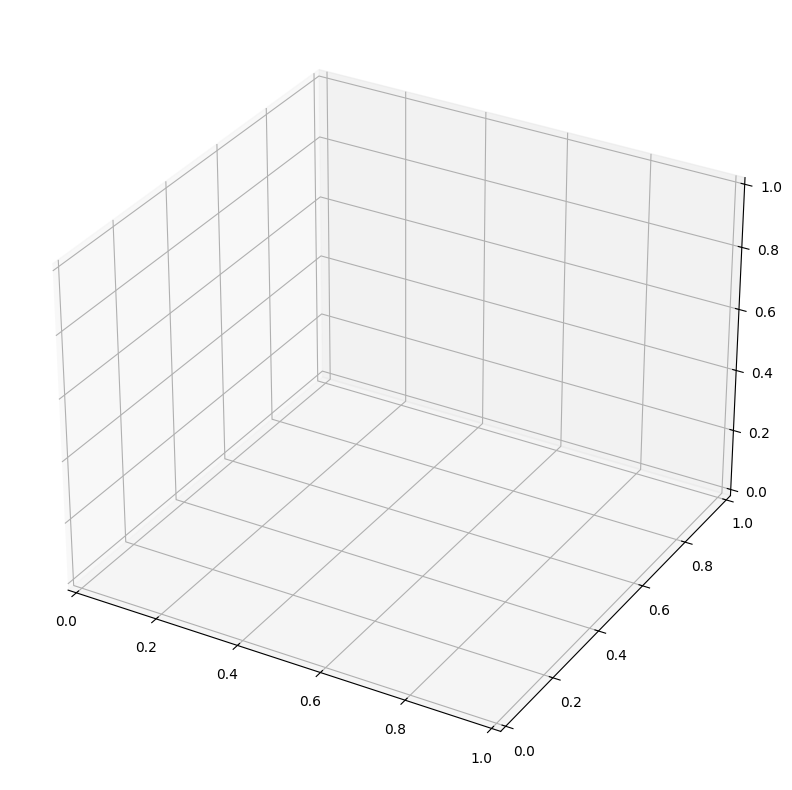

In [17]:
plot_3d_interval_history(
    history=loaded_states,
    dim_names=dim_names,
    save_to_pdf=True,
    color_map=None,
    pdf_pages=None,
)

In [ ]:
from datetime import datetime



In [ ]:
def plot_staged_intervals_generalized_sensor(
    u_ols: jnp.ndarray,
    x_interval: irx,
    p_nominal: irx,
    p_faults: List[irx],
    fault_names: List[str],
    w_biases: Optional[jnp.ndarray] = None, # <-- NEW ARGUMENT
    fault_colors: Optional[List[str]] = None,
    dt: float = 0.1,
    num_u_steps: int = 10,
    plot_derivatives: bool = True,
    save_to_pdf: bool = False
) -> Dict[str, Any]:
    """
    Propagates and plots interval evolution, including optional sensor bias faults.
    
    Args:
        ...
        w_biases: (Optional) An array of bias vectors. Each vector defines a
                  sensor bias fault scenario. Shape: (num_biases, state_dim).
        ...
    """
    if plt is None:
        print("Skipping plotting as Matplotlib is not available.")
        return {}

    # --- 1. Unified Scenario and Parameter Setup ---
    assert len(p_faults) == len(fault_names), "Length of p_faults and fault_names must match."
    
    all_scenario_names = ["Nominal"] + fault_names
    all_params = [p_nominal] + p_faults
    zero_bias = jnp.zeros_like(x_interval.lower)
    all_biases = [zero_bias] * len(all_params)
    
    bias_fault_names = []
    if w_biases is not None:
        num_bias_faults = w_biases.shape[0]
        bias_fault_names = [f"Sensor Bias {i+1}" for i in range(num_bias_faults)]
        all_scenario_names.extend(bias_fault_names)
        all_params.extend([p_nominal] * num_bias_faults)
        all_biases.extend([w for w in w_biases])

    all_fault_names = fault_names + bias_fault_names
    if fault_colors is None:
        cmap = plt.cm.get_cmap('viridis', len(all_fault_names))
        generated_colors = [cmap(i) for i in range(len(all_fault_names))]
    else:
        assert len(fault_colors) == len(all_fault_names), "Color list must match total number of faults."
        generated_colors = fault_colors
    color_map = {"Nominal": "blue", **{name: color for name, color in zip(all_fault_names, generated_colors)}}

    # --- 2. Simulation with Bias Application ---
    num_stages = u_ols.shape[0]
    total_sim_steps = num_stages * num_u_steps
    history = {name: {"states": [x_interval], "derivatives": []} for name in all_scenario_names}
    current_states = [copy.deepcopy(x_interval) for _ in all_scenario_names]

    print(f"Simulating {len(all_scenario_names)} scenarios for {total_sim_steps} total steps...")
    for stage_idx in range(num_stages):
        u_current_stage = u_ols[stage_idx]
        for _ in range(num_u_steps):
            for j, name in enumerate(all_scenario_names):
                p_current, x_current, bias_vec = all_params[j], current_states[j], all_biases[j]
                
                derivatives_ut = admire_embsys.f(0, irx.i2ut(x_current), u_current_stage, p_current)
                derivative_ivl = irx.ut2i(derivatives_ut)
                history[name]["derivatives"].append(derivative_ivl)
                
                new_state_unbiased = (derivative_ivl * dt) + x_current
                new_state_biased = new_state_unbiased + bias_vec # Apply bias
                
                history[name]["states"].append(new_state_biased)
                current_states[j] = new_state_biased

    # --- 3. Data Preparation for Plotting ---
    time_axis_states = jnp.arange(total_sim_steps + 1) * dt
    time_axis_derivs = jnp.arange(total_sim_steps) * dt
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    plot_data = {name: {"states_lower": jnp.stack([ivl.lower for ivl in history[name]["states"]]),
                        "states_upper": jnp.stack([ivl.upper for ivl in history[name]["states"]]),
                        "derivs_lower": jnp.stack([ivl.lower for ivl in history[name]["derivatives"]]),
                        "derivs_upper": jnp.stack([ivl.upper for ivl in history[name]["derivatives"]])}
                 for name in all_scenario_names}

    # --- 4. Plotting Setup with Optional PDF ---
    pdf_pages = None
    if save_to_pdf:
        timestamp = datetime.now().strftime('%Y%m%d%H%M%S')
        filename = f"staged_interval_plots_{timestamp}.pdf"
        pdf_pages = PdfPages(filename)
        print(f"Plots will be saved to: {filename}")
    else:
        print("Generating plots to display...")

    # --- 5. Main Plotting Loop (This is the formerly omitted section) ---
    num_dims = x_interval.lower.shape[0]

    for dim in range(num_dims):
        if plot_derivatives:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        else:
            fig, ax2 = plt.subplots(1, 1, figsize=(14, 7))

        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # The plotting code iterates through `all_scenario_names`, automatically
        # including the new sensor bias faults without needing any changes.
        for name in all_scenario_names:
            data, color = plot_data[name], color_map[name]
            linestyle = '-' if name == "Nominal" else '--'
            
            if plot_derivatives:
                ax1.plot(time_axis_derivs, data["derivs_lower"][:, dim], color=color, ls=linestyle)
                ax1.plot(time_axis_derivs, data["derivs_upper"][:, dim], color=color, ls=linestyle)
                ax1.fill_between(time_axis_derivs, data["derivs_lower"][:, dim], data["derivs_upper"][:, dim], 
                                 color=color, alpha=0.2, label=f'{name} Interval')

            ax2.plot(time_axis_states, data["states_lower"][:, dim], color=color, ls=linestyle)
            ax2.plot(time_axis_states, data["states_upper"][:, dim], color=color, ls=linestyle)
            ax2.fill_between(time_axis_states, data["states_lower"][:, dim], data["states_upper"][:, dim], 
                             color=color, alpha=0.2, label=f'{name} Interval')

        for stage in range(1, num_stages):
            change_time = stage * num_u_steps * dt
            label = 'Control Change' if stage == 1 else ""
            if plot_derivatives:
                ax1.axvline(x=change_time, color='r', linestyle='-.', linewidth=1.5, label=label)
            ax2.axvline(x=change_time, color='r', linestyle='-.', linewidth=1.5, label=label if not plot_derivatives else "")

        if plot_derivatives:
            ax1.set_title("Derivative Intervals (dx/dt)")
            ax1.set_ylabel('Derivative Value')
            ax1.legend()
            ax1.grid(True, linestyle=':')
        
        ax2.set_title("State Intervals (x)")
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        if save_to_pdf:
            pdf_pages.savefig(fig)
            plt.close(fig)
        else:
            plt.show()

    # --- 6. Finalize PDF ---
    if save_to_pdf:
        pdf_pages.close()
        print("PDF generation complete.")

    return history

In [121]:
# p_fault_list_sensor = copy.deepcopy(p_faults_list)
# fault_names_sensor = copy.deepcopy(fault_names)
# p_fault_list_sensor.append(p_nominal_ivl)
# fault_names_sensor.append("AoA Reading Fault")
# w_biases_sensor = [jnp.zeros(admire.xlen) for _ in range(len(p_faults_list))]
w_biases_sensor=jnp.array([0., 0., 0.1, 0., 0., 0., 0., 0., 0.])
plot_staged_intervals_generalized_sensor(
    u_ols=u_staged_opt,
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_faults=p_faults_list,
    fault_names=fault_names,
    w_biases=w_biases_sensor,
    num_u_steps=5,
    dt = .1,
    save_to_pdf=True,
)

NameError: name 'plot_staged_intervals_generalized_sensor' is not defined